In [2]:
import pandas as pd
import numpy as np
from modAL.models import ActiveLearner
from modAL.uncertainty import entropy_sampling, margin_sampling, uncertainty_sampling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from tensorflow import keras
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Activation, AveragePooling2D, Conv2DTranspose, ZeroPadding2D
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten, Conv1D, BatchNormalization
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
import random
import scipy

from matplotlib import pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

font_size = 18

In [3]:
# load numpy raw data
with open('all_ae.npy', 'rb') as f:
    h2_ae = np.load(f)
    Pos = np.load(f)

h2_ae_shape = h2_ae.shape
h2_ae_1dcnn = h2_ae.reshape(h2_ae_shape[0], h2_ae_shape[1], -1)
h2_ae.shape, Pos.shape

((4979, 56, 37, 32), (4979, 3))

In [29]:
# cluster the dataset for classification
pos_cluster = pd.DataFrame(Pos, columns=["x", "y", "z"])
kmeans = KMeans(n_clusters=3, random_state=42).fit(pos_cluster)
pos_cluster["cluster"] = kmeans.labels_
pos_cluster["cluster"] = pos_cluster["cluster"].replace({0: "cluster 2", 1: "cluster 3", 2: "cluster 1"})
pos_cluster["is_c1"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 1", 'is_c1'] = 1
pos_cluster["is_c2"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 2", 'is_c2'] = 1
pos_cluster["is_c3"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 3", 'is_c3'] = 1
#pos_cluster = pos_cluster[["is_c1", "is_c2", "is_c3"]]
pos_cluster

,x,y,z,cluster,is_c1,is_c2,is_c3
0,88.715899,-86.997243,508.0062,cluster 1,1,0,0
1,31.383361,-214.049233,503.4021,cluster 1,1,0,0
2,233.059802,-304.533326,500.9975,cluster 1,1,0,0
3,443.049984,178.433276,505.9987,cluster 2,0,1,0
4,79.582267,-403.283761,508.2975,cluster 3,0,0,1
...,...,...,...,...,...,...,...
4974,74.568477,-526.581922,507.7050,cluster 3,0,0,1
4975,142.739261,-100.039852,504.6203,cluster 1,1,0,0
4976,377.462280,208.577331,510.6982,cluster 2,0,1,0
4977,145.629091,-437.464304,508.0232,cluster 3,0,0,1


In [34]:
print("train-test splitting ae data...")
x_train_ae, x_test_ae, y_train_ae, y_test_ae = train_test_split(h2_ae, pos_cluster, test_size=0.1, random_state=42)
x_train_ae_cnn, x_test_ae_cnn, y_train, y_test = train_test_split(h2_ae_1dcnn, pos_cluster, test_size=0.1, random_state=42)

y_train_ae_cnn = y_train[["x", "y", "z"]].values
y_test_ae_cnn = y_test[["x", "y", "z"]].values
print("splitting training data and active learning pool...")
train_x_al, pool_x_al, train_y_al, pool_y_al = train_test_split(x_train_ae_cnn, y_train_ae_cnn, test_size=0.8, random_state=42)

y_train_cluster = y_train[["is_c1", "is_c2", "is_c3"]].values
y_test_cluster = y_test[["is_c1", "is_c2", "is_c3"]].values

train-test splitting ae data...
splitting training data and active learning pool...


In [35]:
y_train

,x,y,z,cluster,is_c1,is_c2,is_c3
1084,376.513266,96.283687,502.5135,cluster 2,0,1,0
4219,124.247961,-143.532413,505.3790,cluster 1,1,0,0
807,310.787392,-173.893854,498.3682,cluster 1,1,0,0
4615,101.410509,-72.299164,505.9455,cluster 1,1,0,0
501,371.132087,186.804475,509.3454,cluster 2,0,1,0
...,...,...,...,...,...,...,...
4426,118.402283,-216.739038,508.3243,cluster 1,1,0,0
466,186.176357,-497.924321,502.4091,cluster 3,0,0,1
3092,43.184485,-156.458712,506.5750,cluster 1,1,0,0
3772,180.027661,-228.458650,503.2688,cluster 1,1,0,0


In [28]:
y_train_ae_cnn[0], y_train_cluster.values[0]

(array([376.5132656 ,  96.28368698, 502.5135    ]), array([0, 1, 0]))

In [23]:
# create 1-d cnn model
def cnn_model1(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt)
    return model

lr = 5e-3
epochs = 50
decay_rate = lr / 50
model_ae = cnn_model1(x_train_ae_cnn.shape[1:], opt=Adam(5e-3, decay=decay_rate))

# model for outputting probability
def cnn_model_clf(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

model_clf = cnn_model_clf(x_train_cluster.shape[1:], opt=Adam(5e-3, decay=decay_rate))

In [24]:
model_clf.fit(x_train_cluster, y_train_cluster, epochs=3, validation_data=(
    x_test_cluster, y_test_cluster), verbose=1)
#kfold = KFold(n_splits=10, shuffle=True)
#results = cross_val_score(model_clf, h2_ae_1dcnn, pos_cluster, cv=kfold, scoring="accuracy")
#print("Baseline: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Epoch 1/3
141/141 [==============================] - 7s 47ms/step - loss: 0.9338 - accuracy: 0.5813 - val_loss: 0.8791 - val_accuracy: 0.6586
Epoch 2/3
141/141 [==============================] - 6s 43ms/step - loss: 0.8515 - accuracy: 0.6202 - val_loss: 1.2565 - val_accuracy: 0.4116
Epoch 3/3
141/141 [==============================] - 6s 41ms/step - loss: 0.7992 - accuracy: 0.6396 - val_loss: 1.3252 - val_accuracy: 0.5181


In [22]:
model_clf.predict_proba(x_test_cluster)

Instructions for updating:
Please use `model.predict()` instead.


array([[5.73688792e-03, 9.22557712e-01, 7.17054382e-02],
       [9.79831994e-01, 4.46621380e-06, 2.01636013e-02],
       [1.44815305e-02, 8.70118678e-01, 1.15399770e-01],
       ...,
       [1.10211512e-02, 8.87663364e-01, 1.01315528e-01],
       [9.88794923e-01, 6.67733161e-07, 1.12043321e-02],
       [8.27463150e-01, 7.15896895e-04, 1.71820909e-01]], dtype=float32)

In [91]:
mean_squared_error([1,1],[3,2])

2.5

In [68]:
#model_ae = keras.models.load_model('preds/model_ae', compile=False)

#opt = Adam(5e-3, decay=decay_rate)
#model_ae.compile(loss='mean_squared_error', optimizer=opt)

def get_prediction_precision(regressor, x_test, y_test):
    y_pred = regressor.predict(x_test)
    mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
    print(f"current MSE: {mse}")

regressor = ActiveLearner(
    estimator=model_ae,
    query_strategy=uncertainty_sampling,
    X_training=core_x, y_training=core_y
)
get_prediction_precision(model_ae, test_x, test_y)

307/307 [==============================] - 4s 14ms/sample - loss: 17681.8576
current MSE: 19932.938444005613


In [69]:
n_queries = 500
pool_x_values = pool_x
pool_y_values = pool_y
for idx in range(n_queries):
    if idx % 50 == 0:
        print(idx)
        get_prediction_precision(regressor, test_x, test_y)
    query_idx, query_instance = regressor.query(pool_x_values)
    regressor.teach(pool_x_values[query_idx], pool_y_values[query_idx])

0
current MSE: 19932.938444005613


308/308 [==============================] - 1s 4ms/sample - loss: 12104.4614


309/309 [==============================] - 1s 4ms/sample - loss: 9068.3169


310/310 [==============================] - 1s 4ms/sample - loss: 7666.8026


311/311 [==============================] - 1s 4ms/sample - loss: 6528.5471


...

803/803 [==============================] - 5s 6ms/sample - loss: 209.1377


804/804 [==============================] - 4s 5ms/sample - loss: 152.2146


805/805 [==============================] - 3s 4ms/sample - loss: 198.3158


806/806 [==============================] - 3s 4ms/sample - loss: 358.2349


807/807 [==============================] - 3s 4ms/sample - loss: 243.7063


In [72]:
get_prediction_precision(model_ae, test_x, test_y)

current MSE: 147785430.01503325


In [28]:
x_train_ae, x_test_ae, y_train_ae, y_test_ae = train_test_split(h2_ae_1dcnn, Pos, test_size=0.1, random_state=42)

In [26]:
preds = model_ae.predict(x_test_ae)
result = pd.DataFrame(preds, columns=["x", "y", "z"])
result.to_csv("preds/cnn_ae_preds_macbook.csv")

In [37]:
def analyze_predictions(y_test, x_test=None, file=None, model=None):
    if x_test is not None:
        preds = model.predict(x_test)
        preds = pd.DataFrame(preds, columns=["x", "y", "z"])
    else:
        preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    sns.set()
    plt.figure(figsize=(12, 8))
    concat = concat[concat["x"]<1000]
    sns.scatterplot(x="x", y="y", data=concat, hue="type")
    #return concat

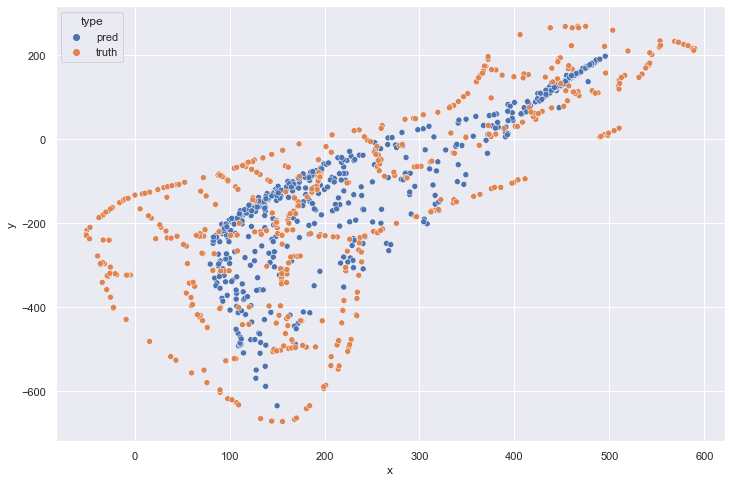

In [38]:
concat = analyze_predictions(y_test_ae, file="cnn_ae_al2_uncertainty_all_preds.csv")

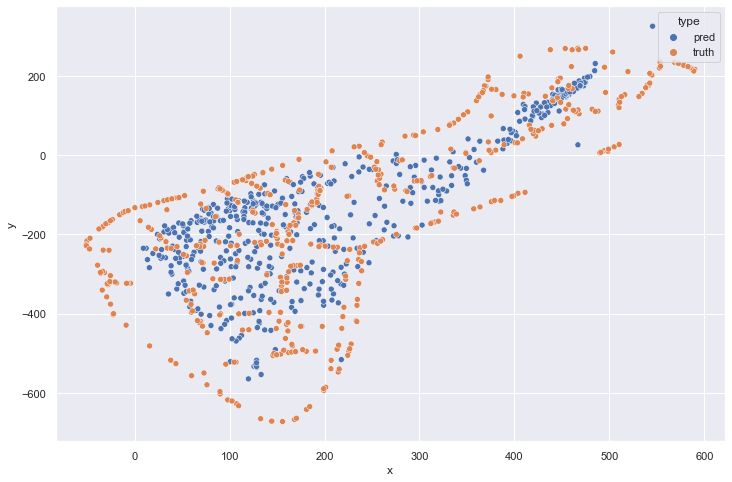

In [84]:
concat = analyze_predictions(y_test_ae, file="cnn_ae_al1_random_all_preds.csv")

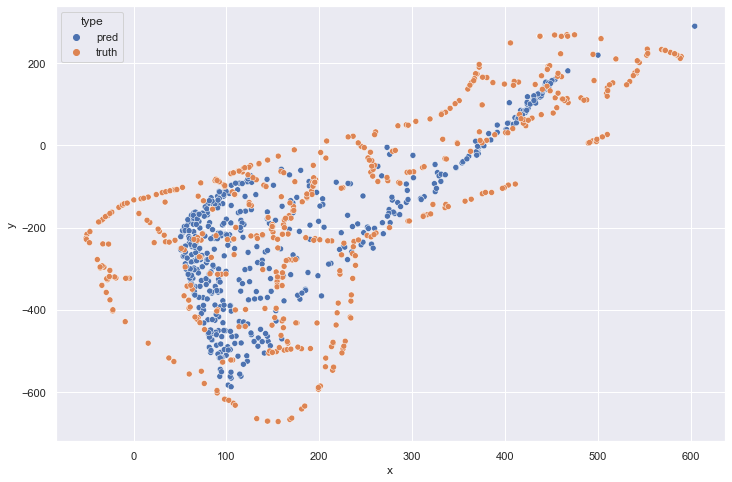

In [87]:
concat = analyze_predictions(y_test_ae, file="cnn_ae_al1_margin_all_preds.csv")

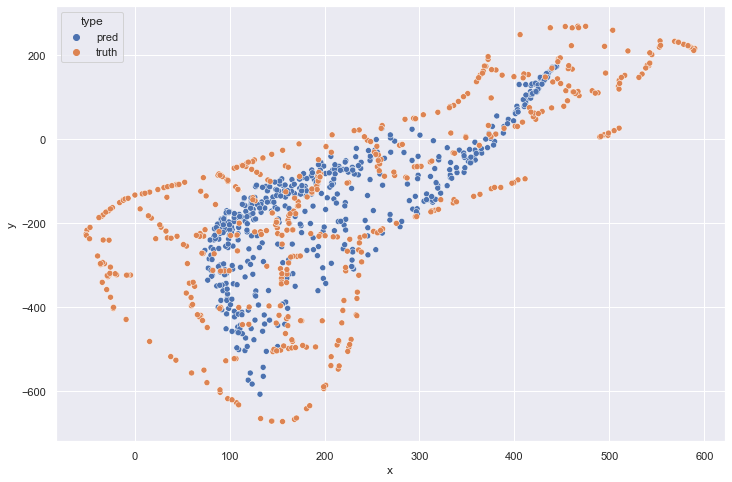

In [95]:
concat = analyze_predictions(y_test_ae, file="cnn_ae_al1_entropy_all_preds.csv")

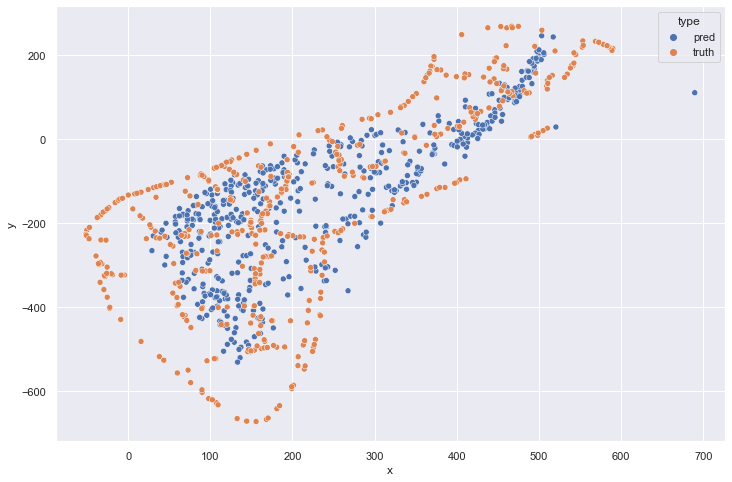

In [106]:
analyze_predictions(y_test_ae, file="cnn_ae_full_all_preds2.csv")

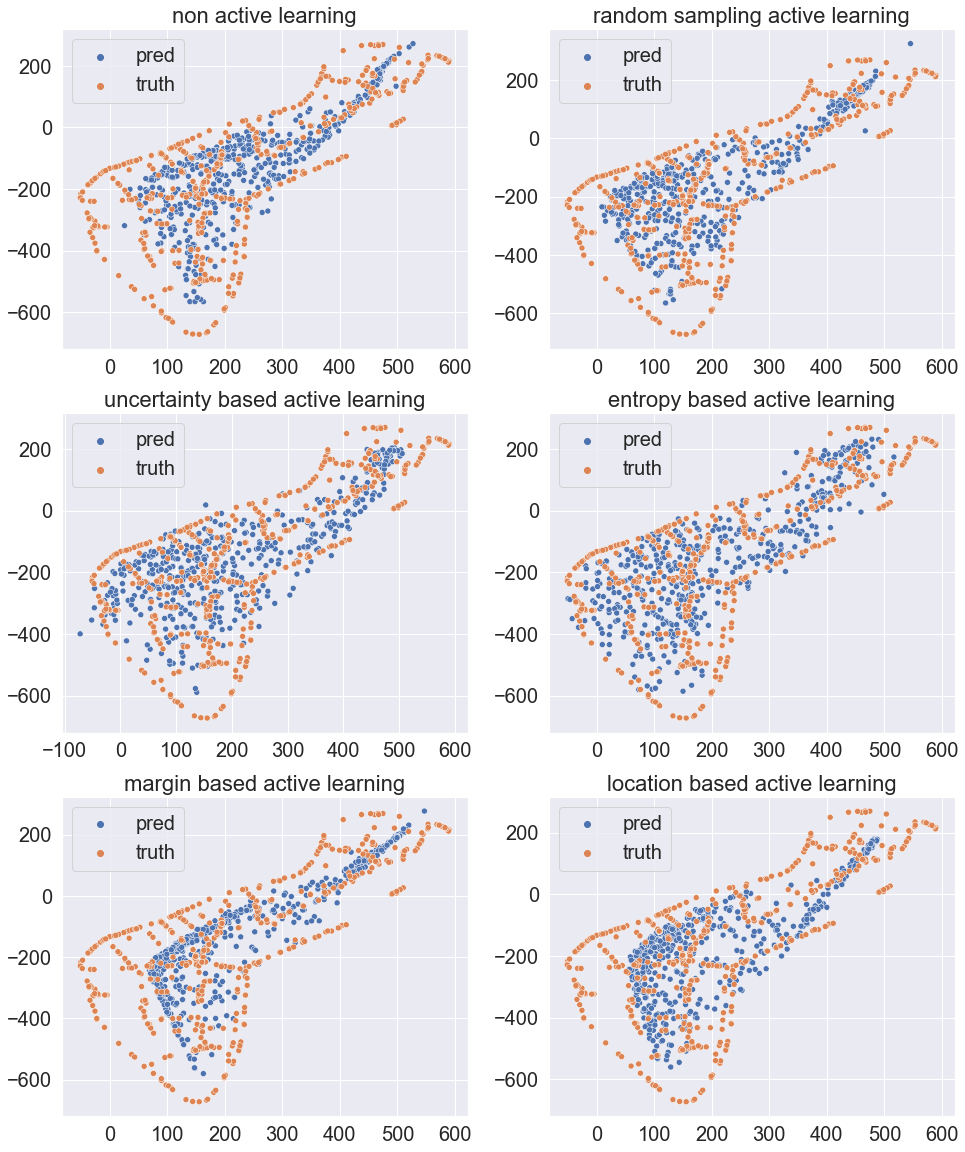

In [102]:
font_size = 20
fs_title = 22
def _plot_qs_comp(y_test, filename, title):
    file = f"{filename}.csv"
    preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    concat = concat[concat["x"]<600]
    ax = sns.scatterplot(x="x", y="y", data=concat, hue="type")
#     plt.ylabel("y", fontsize=font_size)
#     plt.xlabel("x", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    ax.set_title(title, fontsize=fs_title)

def compare_predictions(y_test, x_test=None, model=None):
    plt.subplots(3, 2, figsize=(16, 20))
    plt.subplot(3, 2, 1)
    _plot_qs_comp(y_test, "cnn_ae_full_all_preds", "non active learning")
    
    plt.subplot(3, 2, 2)
    _plot_qs_comp(y_test, "cnn_ae_al1_random_all_preds", "random sampling active learning")

    plt.subplot(3, 2, 3)
    _plot_qs_comp(y_test, "cnn_ae_al2_uncertainty_all_preds", "uncertainty based active learning")
    
    plt.subplot(3, 2, 4)
    _plot_qs_comp(y_test, "cnn_ae_al2_entropy_all_preds", "entropy based active learning")
    
    plt.subplot(3, 2, 5)
    _plot_qs_comp(y_test, "cnn_ae_al2_margin_all_preds", "margin based active learning")
    
    plt.subplot(3, 2, 6)
    _plot_qs_comp(y_test, "cnn_ae_al1_lb_all_preds", "location based active learning")
    
    
compare_predictions(y_test_ae)

Text(0.5, 1.0, 'shuffle attempt 2')

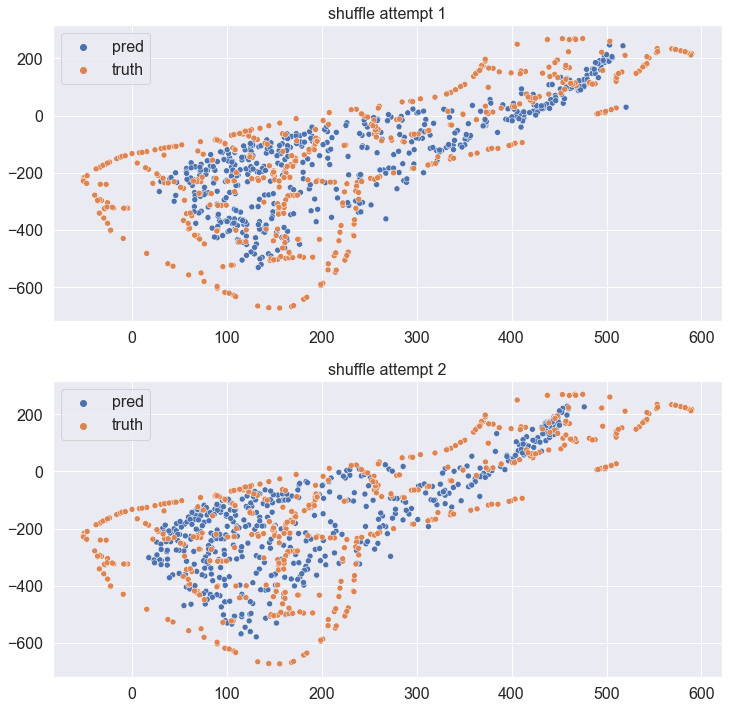

In [113]:
plt.subplots(2, 1, figsize=(12, 12))

file1 = "cnn_ae_full_all_preds2.csv"
preds1 = pd.read_csv(f"preds/{file1}")
preds1 = preds1[["x", "y", "z"]]
preds1["type"] = "pred"
truth = pd.DataFrame(y_test_ae, columns=["x", "y", "z"])
truth = truth[["x", "y", "z"]]
truth["type"] = "truth"
concat1 = pd.concat([preds1, truth], ignore_index=True)
concat1 = concat1[concat1["x"]<600]
sns.set()

plt.subplot(2, 1, 1)
ax1 = sns.scatterplot(x="x", y="y", data=concat1, hue="type")
fontsize = 16
#plt.ylabel("y", fontsize=font_size)
#plt.xlabel("x", fontsize=font_size)
ax1.xaxis.label.set_visible(False)
ax1.yaxis.label.set_visible(False)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
ax1.set_title("shuffle attempt 1", fontsize=fontsize)


file2 = "cnn_ae_full_all_preds3.csv"
preds2 = pd.read_csv(f"preds/{file2}")
preds2 = preds2[["x", "y", "z"]]
preds2["type"] = "pred"
concat2 = pd.concat([preds2, truth], ignore_index=True)
concat2 = concat2[concat2["x"]<600]
plt.subplot(2, 1, 2)
ax2 = sns.scatterplot(x="x", y="y", data=concat2, hue="type")
ax2.xaxis.label.set_visible(False)
ax2.yaxis.label.set_visible(False)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
ax2.set_title("shuffle attempt 2", fontsize=fontsize)

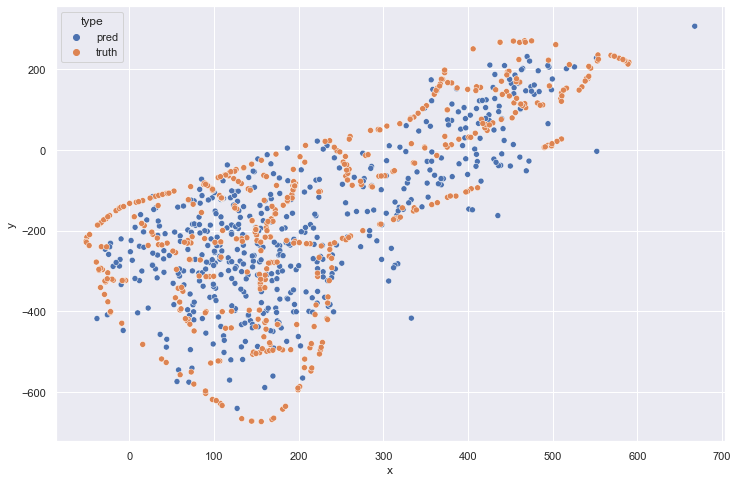

In [121]:
analyze_predictions(y_test_ae_cnn, file="cnn_ae_full_all_preds_100iter.csv")

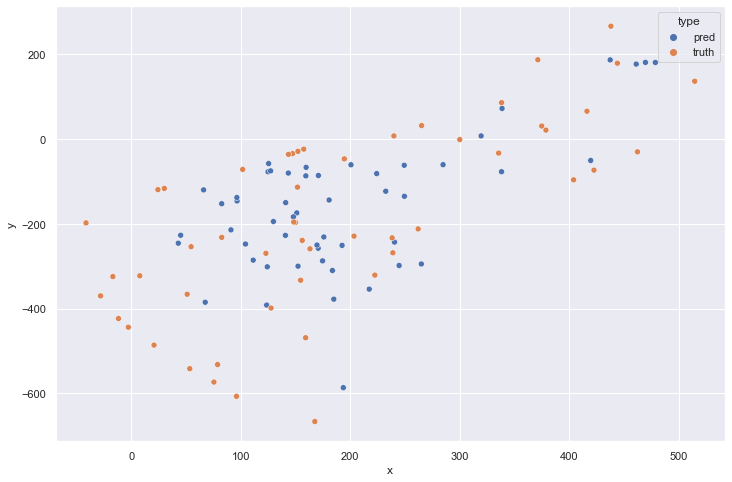

In [86]:
analyze_predictions(y_test_ae_cnn, file="cnn_ae_al_300_preds.csv")

In [71]:
def get_prediction_precision(regressor, x_test, y_test):
    y_pred = regressor.predict(x_test)
    mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
    print(f"current MSE: {mse}")
    
model_ae = keras.models.load_model('models/model_ae_active_learning.h5', compile=False)
get_prediction_precision(model_ae, x_test_ae_cnn, y_test_ae_cnn)

current MSE: 24062.55206834081


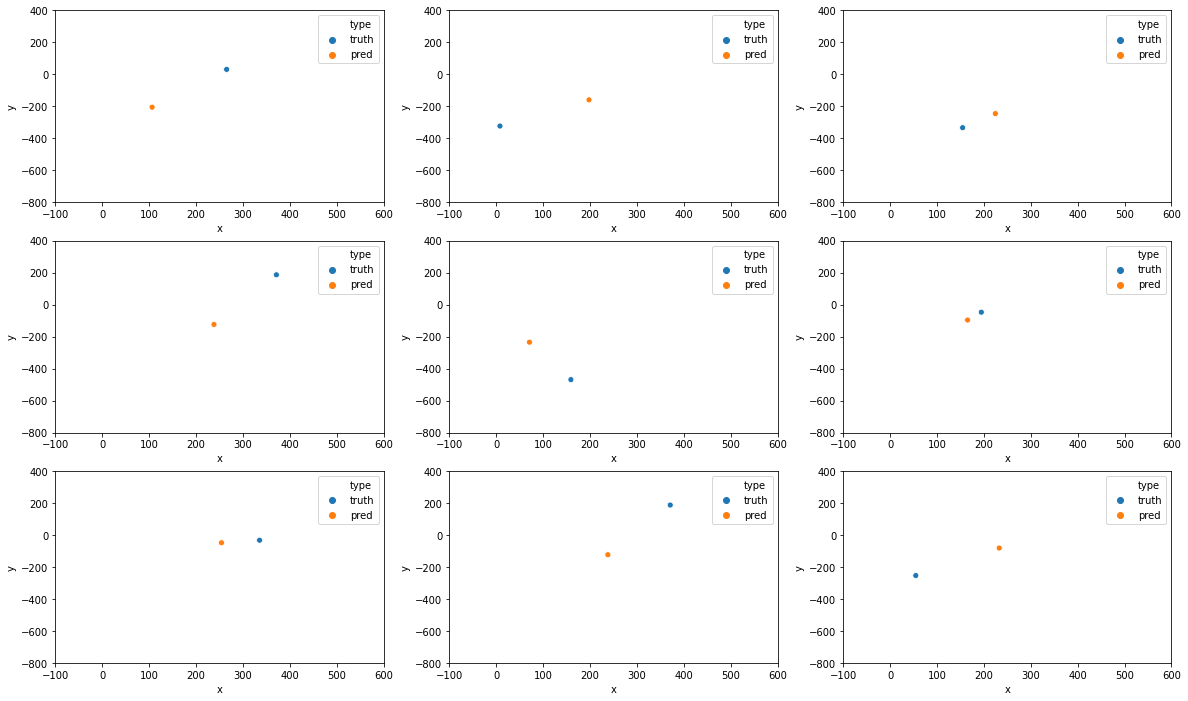

In [62]:
def plot_random_dots(model, x_test, y_test):
    random_choices = random.choices(list(zip(x_test, y_test)), k=9)
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))
    for idx, (_x, _y) in enumerate(random_choices):
        _y_pred = model.predict(np.array([_x]))
        _df_y = pd.DataFrame([_y], columns=["x", "y", "z"])
        _df_y["type"] = "truth"
        _df_y_pred = pd.DataFrame(_y_pred, columns=["x", "y", "z"])
        _df_y_pred["type"] = "pred"
        _df = pd.concat([_df_y, _df_y_pred], ignore_index=True)
        ax = plt.subplot(3, 3, idx + 1)
        g = sns.scatterplot(x="x", y="y", data=_df, hue="type")
        g.set(ylim=(-800, 400))
        g.set(xlim=(-100, 600))
    
plot_random_dots(model_ae, x_test_ae_cnn, y_test_ae_cnn)

current MSE: 1923516130.9913874


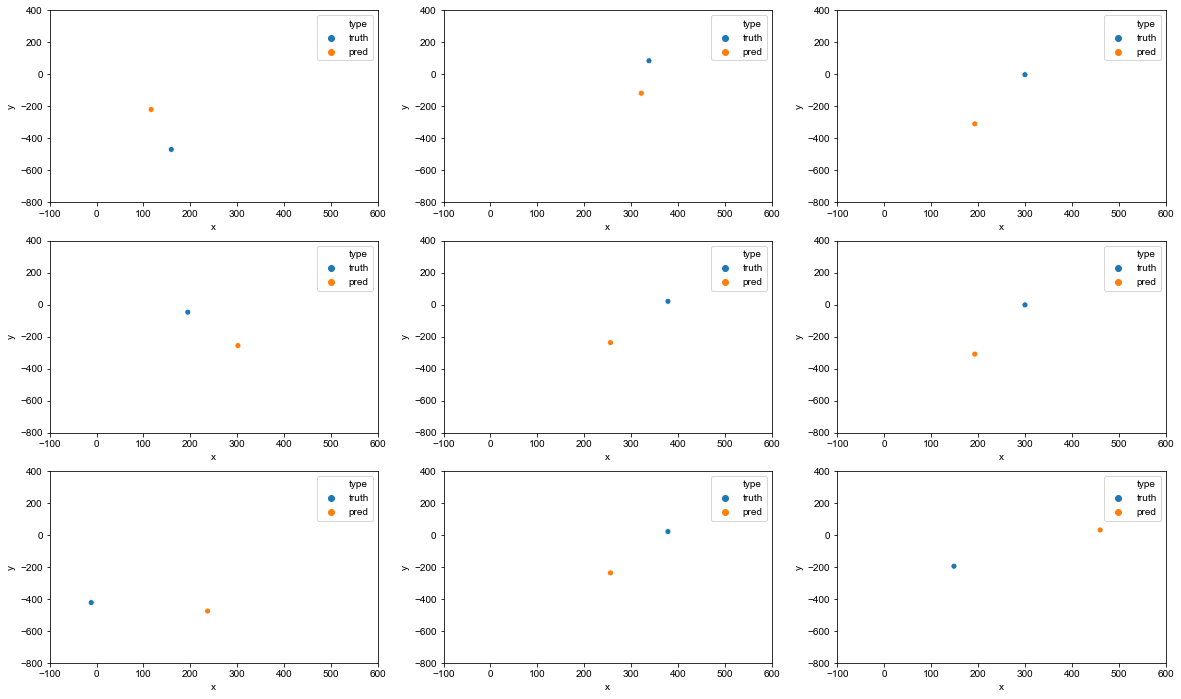

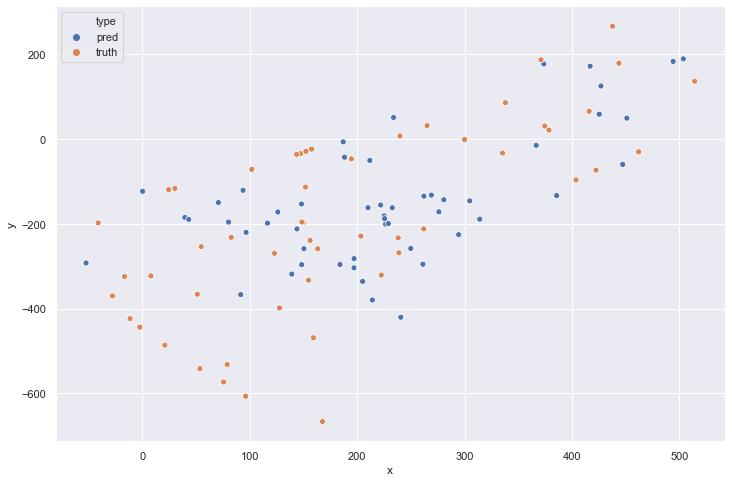

In [74]:
model = keras.models.load_model('models/model_ae_al_entropy_sampling.h5', compile=False)
get_prediction_precision(model, x_test_ae_cnn, y_test_ae_cnn)
plot_random_dots(model, x_test_ae_cnn, y_test_ae_cnn)
analyze_predictions(y_test_ae_cnn, file="cnn_ae_al_es_300_preds.csv")

current MSE: 51485.2424100502


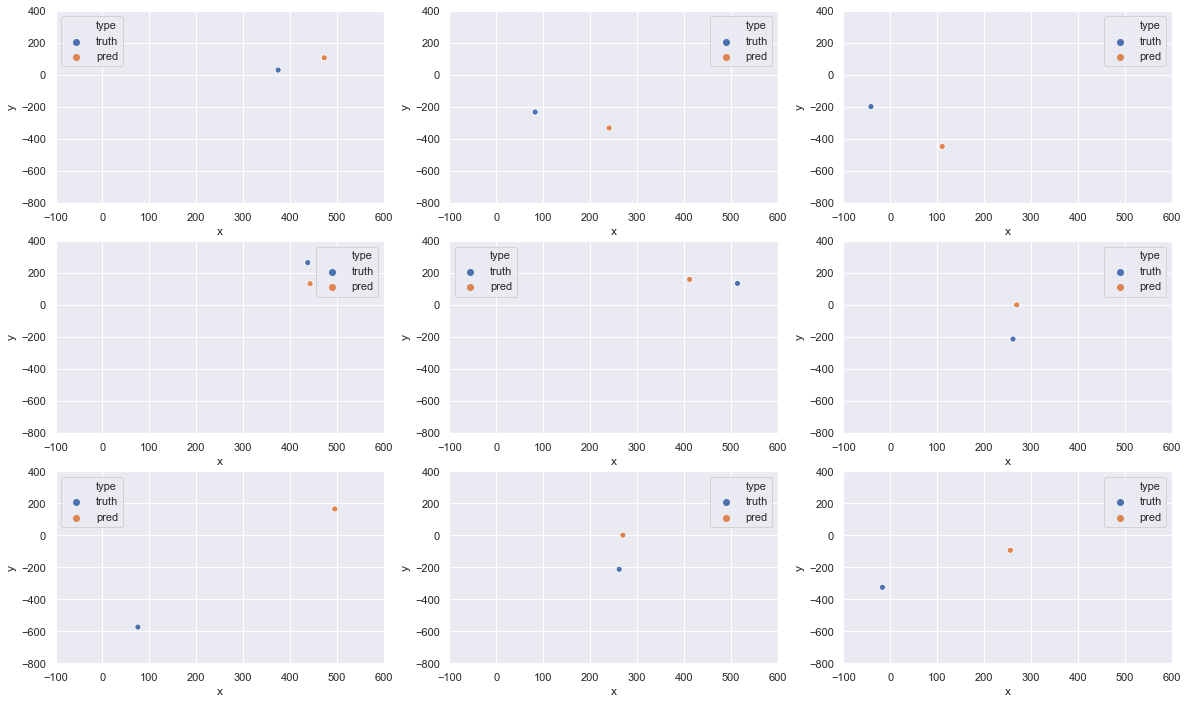

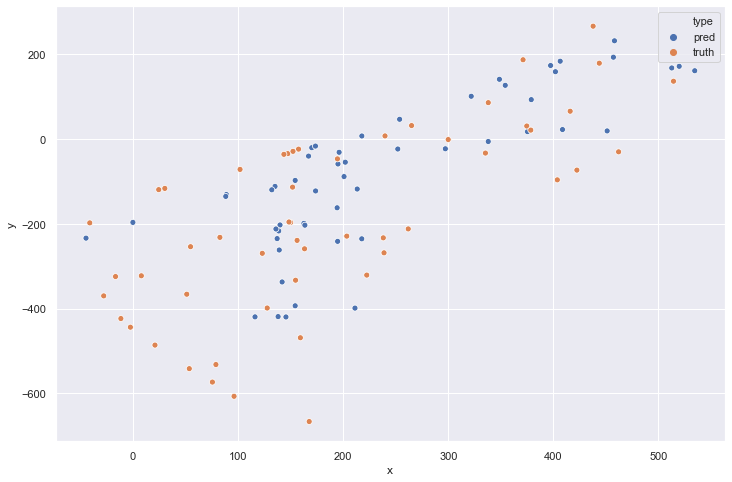

In [79]:
model = keras.models.load_model('models/model_ae_al_margin.h5', compile=False)
get_prediction_precision(model, x_test_ae_cnn, y_test_ae_cnn)
plot_random_dots(model, x_test_ae_cnn, y_test_ae_cnn)
analyze_predictions(y_test_ae_cnn, file="cnn_ae_al_margin_300_preds.csv")

<AxesSubplot:xlabel='x', ylabel='y'>

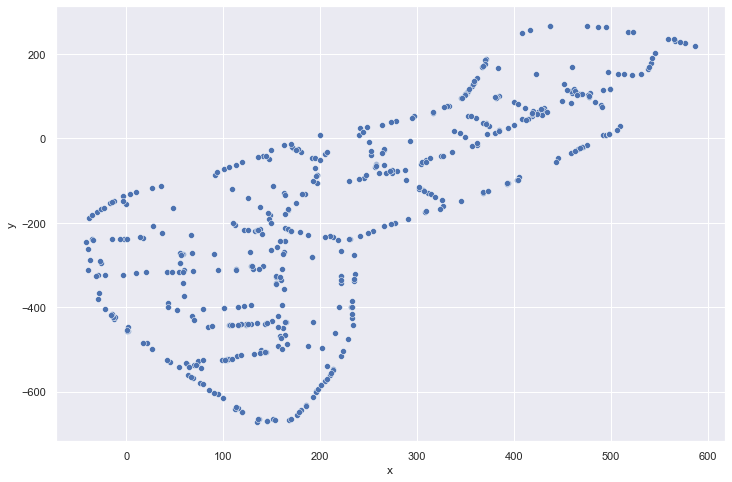

In [53]:
# Looking at the chosen samples by the uncertainty sampling method
df_chosen = pd.read_csv("chosen/cnn_ae_al2_uncertainty_all_chosen_500iter.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)
sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_chosen)

<AxesSubplot:xlabel='x', ylabel='y'>

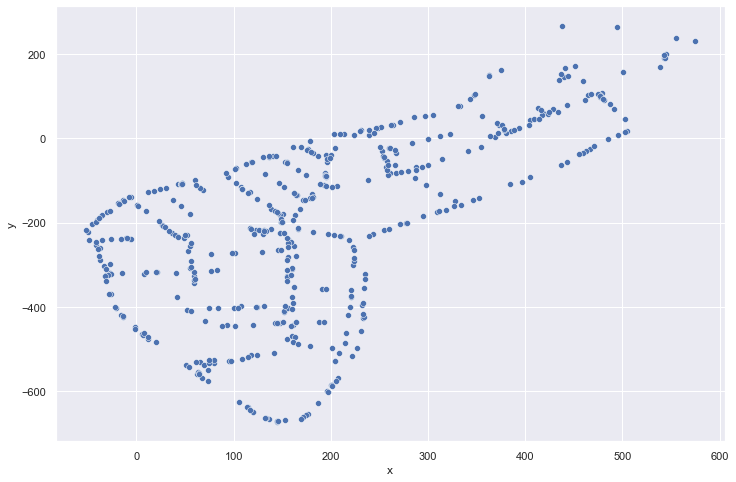

In [54]:
# Looking at the chosen samples by the random sampling method
df_chosen = pd.read_csv("chosen/cnn_ae_al2_margin_all_chosen_500iter.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)
sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_chosen)

In [ ]:
# Looking at the chosen samples by the random sampling method
df_chosen = pd.read_csv("chosen/cnn_ae_al1_random_all_chosen_500iter.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)
sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_chosen)

In [160]:
xpar = df_pool["x"].mean()
ypar = df_pool["y"].mean()
df_chosen["var_x"] = np.square(df_chosen["x"] - xpar)
df_chosen["var_y"] = np.square(df_chosen["y"] - xpar)
df_chosen["var_x"].mean(), df_chosen["var_y"].mean()

(25566.487229265716, 195181.85316906308)

,x,y,z,iter,size
0,491.671001,114.602384,501.4656,1.0,1.000000
1,509.835469,30.994140,497.0630,2.0,1.000000
2,353.878089,-17.579918,500.0251,3.0,1.000000
3,434.536927,70.821939,501.7079,4.0,1.000000
4,464.852069,223.968376,512.2948,5.0,1.000000
...,...,...,...,...,...
246,374.522916,30.662891,502.0960,247.0,0.040000
247,11.078706,-320.104397,507.6873,248.0,0.040000
248,380.692566,13.590466,518.5371,249.0,0.040000
249,154.335907,-343.905337,504.0147,250.0,0.038462


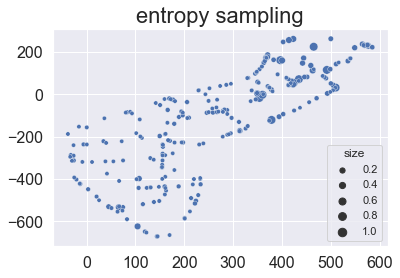

In [87]:
df_chosen = pd.read_csv(f"chosen/cnn_ae_al2_entropy_all_chosen_250iter.csv", index_col=0)
df_chosen["iter"] = df_chosen["iter"] + 1
batch = 10
df_chosen["size"] = df_chosen["iter"].apply(lambda val: 1 / (((val - (val % batch)) / batch) + 1))
sns.set()
#plt.subplot(3, 2, idx)
ax = sns.scatterplot(x="x", y="y", data=df_chosen, size="size")
plt.title(f"entropy sampling", fontsize=fs_title)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)
ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)
df_chosen

,x,y,z,iter,size
0,490.258737,115.286789,499.3217,1.0,1.000000
1,576.533432,228.324771,503.1025,2.0,1.000000
2,396.446090,160.731043,508.5152,3.0,1.000000
3,514.139053,155.359995,483.0468,4.0,1.000000
4,380.831358,98.598988,505.5095,5.0,1.000000
...,...,...,...,...,...
246,316.501771,-136.160300,501.9840,247.0,0.040000
247,137.033067,-262.746718,502.8657,248.0,0.040000
248,259.686599,-214.141525,501.3868,249.0,0.040000
249,27.526003,-116.669275,509.5378,250.0,0.038462


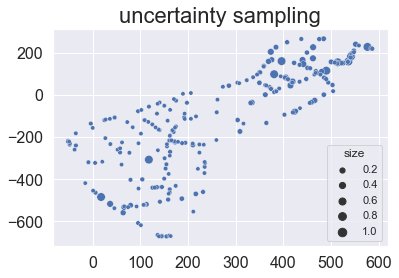

In [89]:
df_chosen = pd.read_csv(f"chosen/cnn_ae_al2_uncertainty_all_chosen_250iter.csv", index_col=0)
df_chosen["iter"] = df_chosen["iter"] + 1
batch = 10
df_chosen["size"] = df_chosen["iter"].apply(lambda val: 1 / (((val - (val % batch)) / batch) + 1))
sns.set()
#plt.subplot(3, 2, idx)
ax = sns.scatterplot(x="x", y="y", data=df_chosen, size="size")
plt.title(f"uncertainty sampling", fontsize=fs_title)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)
ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)
df_chosen

Text(0.5, 1.0, 'location based')

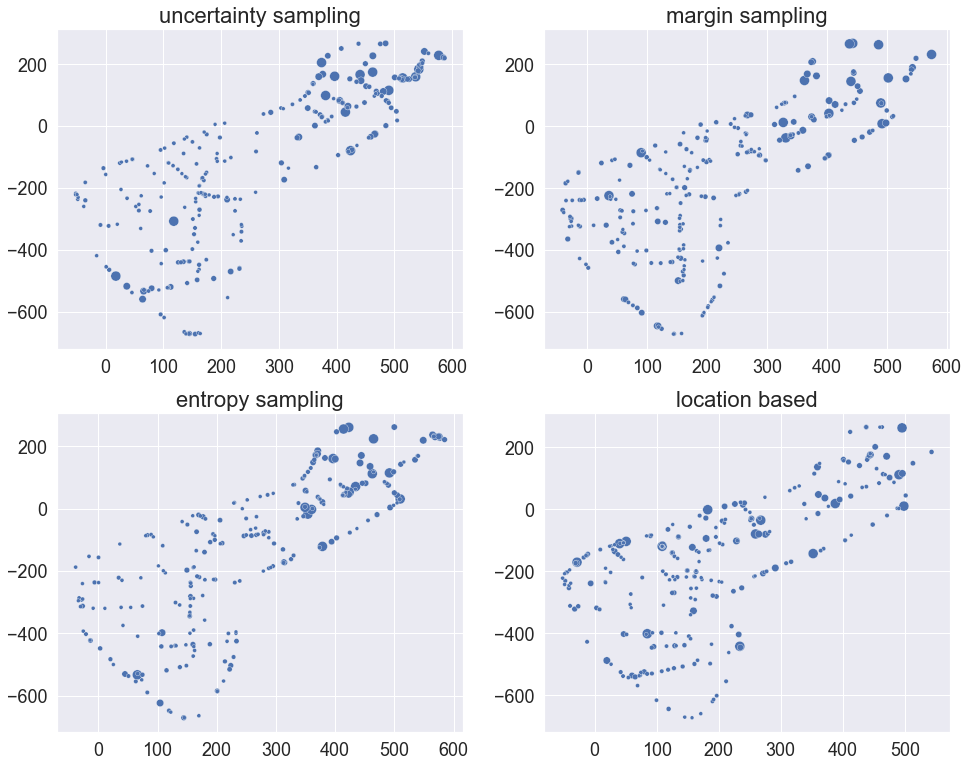

In [100]:
# Looking at the chosen samples by the 4 uncertainty sampling methods
plt.subplots(2, 2, figsize=(16, 20))
font_size = 18
fs_title = 22

def plot_qs_chosen(qs_name, idx):
    df_chosen = pd.read_csv(f"chosen/cnn_ae_al2_{qs_name}_all_chosen_250iter.csv", index_col=0)
    df_chosen["iter"] = df_chosen["iter"] + 1
    batch = 15
    df_chosen["size"] = df_chosen["iter"].apply(lambda val: 5 / (((val - (val % batch)) / batch) + 1))
    sns.set()
    plt.subplot(3, 2, idx)
    ax = sns.scatterplot(x="x", y="y", data=df_chosen, size="size", sizes=(15, 100))
    plt.title(f"{qs_name} sampling", fontsize=fs_title)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.xlabel("MSE", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.get_legend().remove()

#plot_qs_chosen("random", 1)
plot_qs_chosen("uncertainty", 1)
plot_qs_chosen("margin", 2)
plot_qs_chosen("entropy", 3)
plot_qs_chosen("lb", 4)
plt.title("location based", fontsize=fs_title)

(0.0, 70000.0)

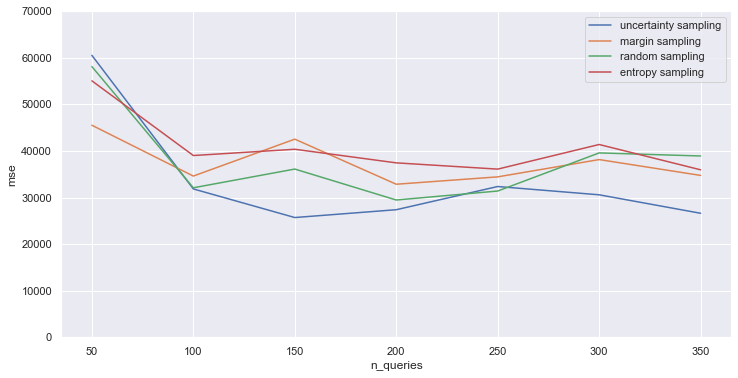

In [46]:
mse_dict_uncertainty = {50.0: 60514.963598684764, 100.0: 31841.695731774857, 150.0: 25702.617941530374, 200.0: 27382.375669336656, 250.0: 32360.619515040435, 300.0: 30582.778518486946, 350.0: 26619.3303561839}
mse_dict_margin = {50.0: 45514.544141457125, 100.0: 34604.536309049574, 150.0: 42527.6121977615, 200.0: 32851.52650554272, 250.0: 34431.60710481097, 300.0: 38141.955207563966, 350.0: 34743.025521364696}
mse_dict_random = {50.0: 58098.87286812463, 100.0: 32087.348195466795, 150.0: 36107.68784990619, 200.0: 29465.876138841555, 250.0: 31393.296501432866, 300.0: 39571.97867319034, 350.0: 38912.98055425642}
mse_dict_entropy = {50.0: 55039.50218029832, 100.0: 39012.07114235836, 150.0: 40357.16221852363, 200.0: 37438.08916797078, 250.0: 36094.12220714579, 300.0: 41378.128857043615, 350.0: 35947.00731654879}
#df_uncertainty = pd.DataFrame.from_dict(mse_dict_uncertainty, orient="index", columns=["uncertainty"])
#df_margin = pd.DataFrame.from_dict(mse_dict_margin, orient="index", columns=["uncertainty"])


n_queries = list(mse_dict.keys())
mses_uncertainty = list(mse_dict_uncertainty.values())
mses_margin = list(mse_dict_margin.values())
mses_random = list(mse_dict_random.values())
mses_entropy = list(mse_dict_entropy.values())


sns.set()
plt.figure(figsize=(12, 6))
plt.plot(n_queries, mses_uncertainty, label="uncertainty sampling")
plt.plot(n_queries, mses_margin, label="margin sampling")
plt.plot(n_queries, mses_random, label="random sampling")
plt.plot(n_queries, mses_entropy, label="entropy sampling")


plt.ylabel("mse")
plt.xlabel("n_queries")
plt.legend()
plt.ylim((0, 70000))

In [ ]:
# expand the # of queries
# active leraning for user localization...
## comparison.
## data points selected
# limited budget

# hybrid method?
# finding the threshold...


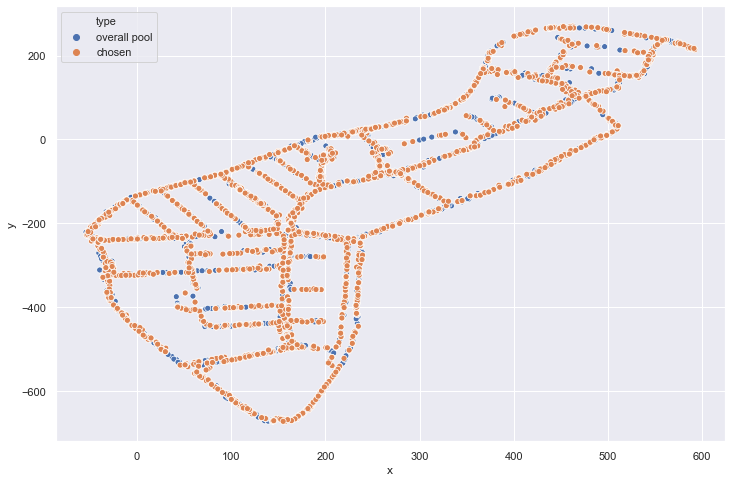

In [175]:
# Looking at the chosen samples by the random sampling method
df_chosen = pd.read_csv("chosen/cnn_ae_al_random_all_chosen.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)

sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_concat, hue="type")

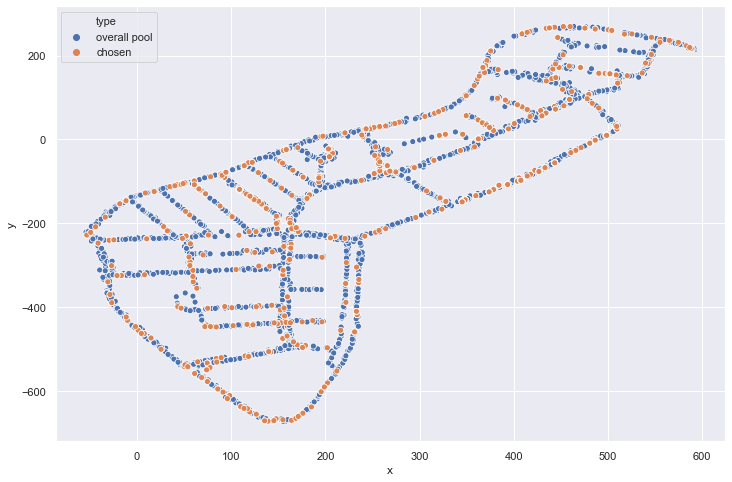

In [174]:
# Looking at the chosen samples by the uncertainty sampling method, based on all input data files
df_chosen = pd.read_csv("chosen/cnn_ae_al_uncertainty_all_chosen.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)

sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_concat, hue="type")

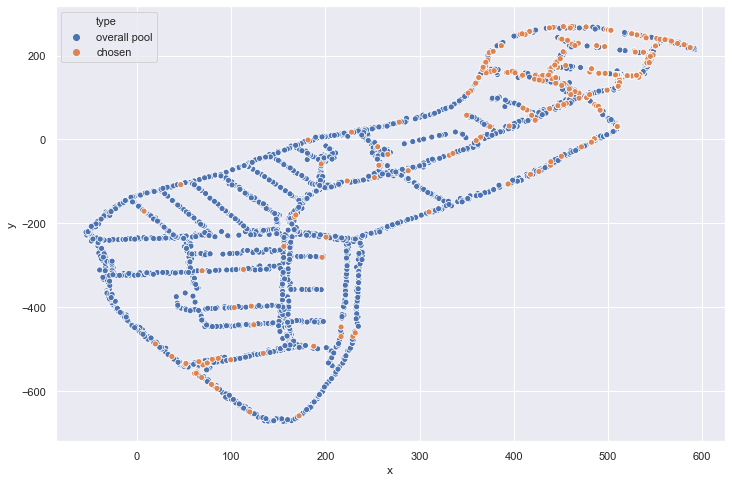

In [176]:
# Looking at the chosen samples by the margin sampling method, based on all input data files
df_chosen = pd.read_csv("chosen/cnn_ae_al_margin_all_chosen.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)

sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_concat, hue="type")

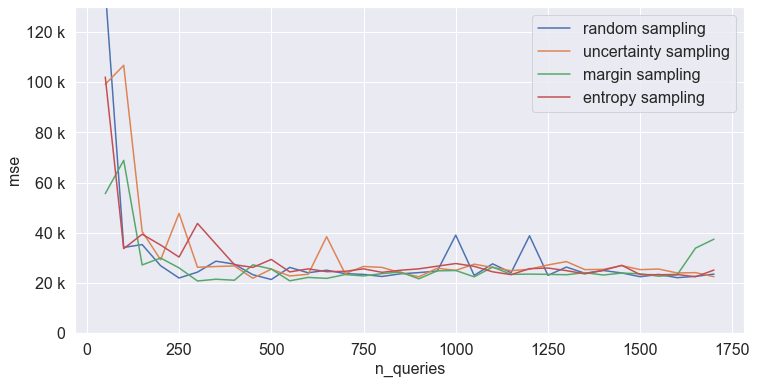

In [90]:
# MSE change over iterations

# mse_dict_random_all = {50: 38603.38415396731, 100: 82370.88192630802, 150: 43307.05292602763, 200: 28484.2737865376, 250: 27579.358404292594, 300: 30343.562950078733, 350: 67701.93577660655, 400: 32299.784316985966, 450: 37145.25167967304, 500: 113835.59726851231, 550: 33100.59150606123, 600: 29357.378790434264, 650: 28080.05916619314, 700: 27614.84726530599, 750: 27448.63793693554, 800: 28529.915769804236, 850: 28165.585971032197, 900: 32210.75674398181, 950: 28451.95431236594, 1000: 30012.122900609294, 1050: 28926.748521576752, 1100: 27067.693911817983, 1150: 26942.316022572108, 1200: 26685.504840593272, 1250: 28146.313804350604, 1300: 26775.50005560768, 1350: 28430.302043754185, 1400: 27960.471410060014, 1450: 29024.794261097184, 1500: 27688.26456234804, 1550: 27045.103976607537, 1600: 27575.284864317913, 1650: 28269.095224999113, 1700: 27458.048376353825, 1750: 25960.281637222113, 1800: 26856.849803309335, 1850: 26811.936223452358, 1900: 26786.63116298782, 1950: 26704.40241480766, 2000: 28146.67630169472, 2050: 29245.853265513928, 2100: 27262.45549392521, 2150: 27920.658066724627, 2200: 27334.347761251072, 2250: 27259.521843977887, 2300: 26982.677144396588, 2350: 25506.16868117935, 2400: 26869.41597787626, 2450: 26662.513962051406, 2500: 26975.975509946104, 2550: 24982.021808489477, 2600: 29977.882378281025, 2650: 27263.024376848523, 2700: 26981.95579496159}
mse_dict_margin_all = {50: 55592.29832206911, 100: 68856.49051663907, 150: 27164.721092246866, 200: 29928.20701588535, 250: 25996.94391543753, 300: 20768.585005200777, 350: 21470.876010521417, 400: 21064.210259788477, 450: 27219.64314444397, 500: 25537.717831508988, 550: 20839.519013170346, 600: 22198.373894967535, 650: 21808.981076780165, 700: 23332.804939999904, 750: 22785.593604459358, 800: 23693.347359738833, 850: 24353.86426780431, 900: 21637.52454548067, 950: 24805.213706801722, 1000: 24954.076186888564, 1050: 22431.910560172764, 1100: 26315.24965119817, 1150: 23413.63402327524, 1200: 23511.47745678872, 1250: 23412.78492836126, 1300: 23254.019518389392, 1350: 24090.747786149648, 1400: 23144.822218982303, 1450: 23933.88575537053, 1500: 23630.651569227906, 1550: 22672.916146139018, 1600: 23192.208529140302, 1650: 33876.72590450898, 1700: 37445.13170930476}

mse_dict_entropy_all = {50: 102075.03976170164, 100: 33660.70636535336, 150: 39404.01573500002, 200: 35112.07391564903, 250: 30297.022116791468, 300: 43713.065023298725, 350: 35461.80480390243, 400: 27281.046985621666, 450: 26189.410686719315, 500: 29356.134358409792, 550: 24392.404242297478, 600: 25597.791748375672, 650: 24493.42889741367, 700: 24615.833237427403, 750: 25604.358182597523, 800: 24225.3445039834, 850: 25049.230518004028, 900: 25608.760911136884, 950: 26675.031258466126, 1000: 27728.58702774689, 1050: 26606.313003983814, 1100: 24429.63001527182, 1150: 23287.554616049078, 1200: 25679.462801015517, 1250: 25927.446075771903, 1300: 24898.10912171924, 1350: 23611.594938072423, 1400: 25041.99636087585, 1450: 27012.527912479647, 1500: 23318.155342416034, 1550: 23268.27113976062, 1600: 23363.83196553453, 1650: 22450.530175158437, 1700: 25121.96707703589}

mse_dict_uncertainty_all = {50: 99168.55319229933, 100: 106737.7608221487, 150: 40507.57993314506, 200: 29226.95009948398, 250: 47702.33639518253, 300: 26235.96226212497, 350: 26546.65367102637, 400: 26761.424175882716, 450: 21862.06694008213, 500: 25487.671367540937, 550: 22775.621299090202, 600: 23450.86779503137, 650: 38416.32378666169, 700: 23723.01818050076, 750: 26549.980874794495, 800: 26189.739491579283, 850: 24057.308166884453, 900: 22444.547333268576, 950: 25852.951374009925, 1000: 24998.703021440484, 1050: 27472.51134567252, 1100: 26190.15715230383, 1150: 24862.332061392546, 1200: 25440.796553500517, 1250: 27167.93965413079, 1300: 28498.3913922542, 1350: 25300.191707868133, 1400: 25401.98880281988, 1450: 26903.46589321538, 1500: 25297.00423120307, 1550: 25537.50647774972, 1600: 23970.191023873802, 1650: 24100.79393282654, 1700: 22480.446288293097}

mse_dict_random_all = {50: 137229.94141681996, 100: 34147.06378409631, 150: 35274.235810026126, 200: 26859.025621202018, 250: 21962.86650987435, 300: 24302.29782886221, 350: 28660.16206663304, 400: 27487.264315139302, 450: 23271.019181913096, 500: 21365.633151779308, 550: 26183.24177478183, 600: 24039.65154029956, 650: 25063.44617968233, 700: 23716.751153621357, 750: 23390.22163634902, 800: 22558.326173670546, 850: 23627.585056174295, 900: 24112.108503412364, 950: 24730.528867903093, 1000: 39049.25395722179, 1050: 22997.492058422704, 1100: 27602.483963055656, 1150: 24074.070144916204, 1200: 38786.78802280617, 1250: 23029.606661444395, 1300: 26307.79280229, 1350: 23862.815947148727, 1400: 24950.770062042866, 1450: 23965.524354258883, 1500: 22467.552755224824, 1550: 23390.404526996546, 1600: 22091.61110784116, 1650: 22618.90439728941, 1700: 23509.38065750618}


n_queries = list(mse_dict_uncertainty_all.keys())
mses_random_all = list(mse_dict_random_all.values())[:len(n_queries)]
mses_uncertainty_all = list(mse_dict_uncertainty_all.values())
mses_margin_all = list(mse_dict_margin_all.values())
mses_entropy_all = list(mse_dict_entropy_all.values())

font_size = 16
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
plt.plot(n_queries, mses_random_all, label="random sampling")
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling")
plt.plot(n_queries, mses_margin_all, label="margin sampling")
plt.plot(n_queries, mses_entropy_all, label="entropy sampling")

plt.ylabel("mse", fontsize=font_size)
plt.xlabel("n_queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 130000))
ax.yaxis.set_major_formatter(ticker.EngFormatter())


In [51]:
len(mse_dict_margin_all)

54

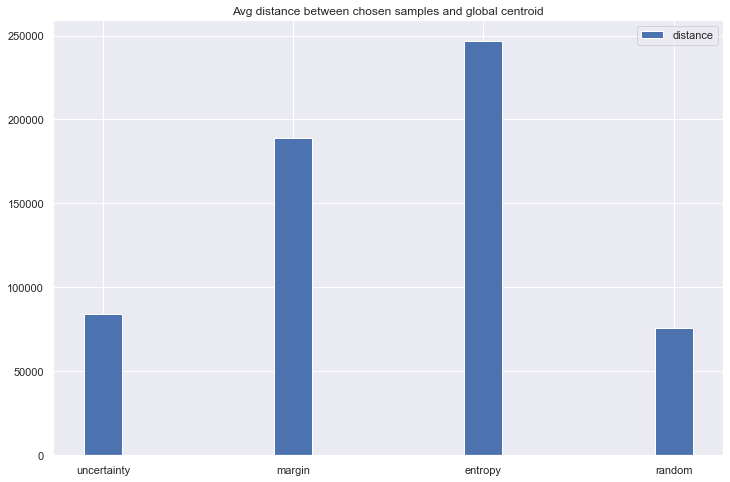

In [29]:
# Avg distance between chosen dots and the global centroid
df_chosen_uncertainty = pd.read_csv("chosen/cnn_ae_al_uncertainty_all_chosen.csv", index_col=0)
df_chosen_margin = pd.read_csv("chosen/cnn_ae_al_margin_all_chosen.csv", index_col=0)
df_chosen_entropy = pd.read_csv("chosen/cnn_ae_al_entropy_all_chosen.csv", index_col=0)
df_chosen_random = pd.read_csv("chosen/cnn_ae_al_random_all_chosen.csv", index_col=0)

#df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"

xpar = df_pool["x"].mean()
ypar = df_pool["y"].mean()
zpar = df_pool["z"].mean()


def cal_distance(_df):
    return np.square(_df["x"] - xpar) + np.square(_df["y"] - ypar) + np.square(_df["z"] - zpar)

df_chosen_uncertainty["distance"] = cal_distance(df_chosen_uncertainty)
df_chosen_margin["distance"] = cal_distance(df_chosen_margin)
df_chosen_entropy["distance"] = cal_distance(df_chosen_entropy)
df_chosen_random["distance"] = cal_distance(df_chosen_random)

dist_uncertainty = df_chosen_uncertainty["distance"].mean()
dist_margin = df_chosen_margin["distance"].mean()
dist_entropy = df_chosen_entropy["distance"].mean()
dist_random = df_chosen_random["distance"].mean()


labels = ["uncertainty", "margin", "entropy", "random"]
plt.figure(figsize=(12, 8))
ax = plt.subplot(111)
#ax2 = ax.twinx()
width = 0.2
x = np.arange(len(labels))

ax.bar(x, [dist_uncertainty, dist_margin, dist_entropy, dist_random], width=width, label="distance")

ax.set_xticks(x)
ax.set_xticklabels(labels)
plt.title("Avg distance between chosen samples and global centroid")
plt.legend()

(array([-800., -600., -400., -200.,    0.,  200.,  400.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

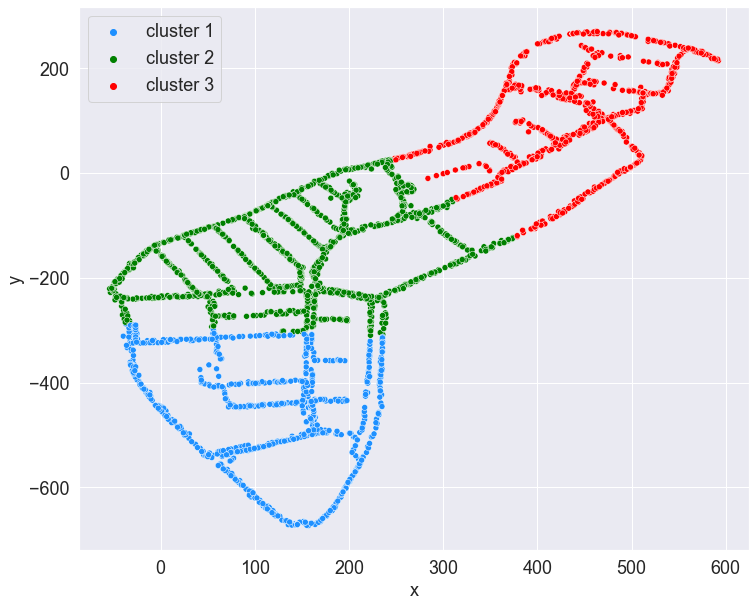

In [30]:
# cluster the dots using KMeans, and calculate the avg distance between chosen dots and cluster centroids

if "type" in df_pool.columns:
    df_pool.drop(columns=["type"], inplace=True)
kmeans = KMeans(n_clusters=3, random_state=42).fit(df_pool)
df_pool["cluster"] = kmeans.labels_
df_pool["cluster"] = df_pool["cluster"].replace({0: "cluster 2", 1: "cluster 3", 2: "cluster 1"})

sns.set()
plt.figure(figsize=(12, 10))
ax = sns.scatterplot(x="x", y="y", data=df_pool, hue="cluster", palette=["dodgerblue", "green", "red"])
plt.ylabel("y", fontsize=font_size)
plt.xlabel("x", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(sorted(handles), sorted(labels)) 

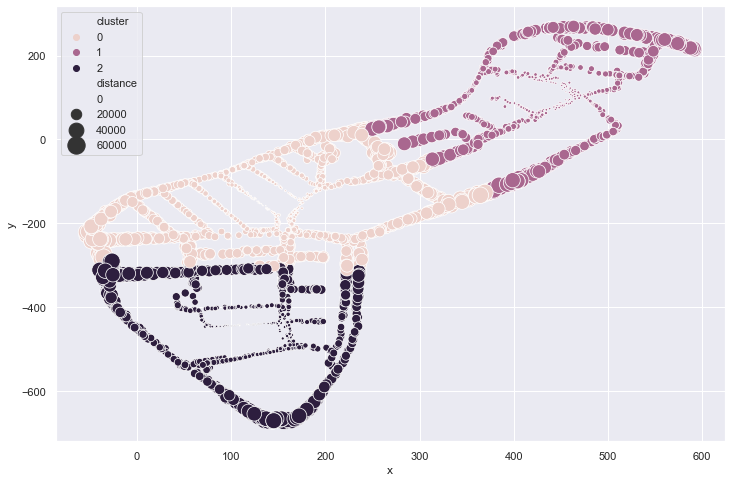

In [19]:
#df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
centroid0 = (df_pool[df_pool["cluster"]==0]["x"].mean(), df_pool[df_pool["cluster"]==0]["y"].mean(), df_pool[df_pool["cluster"]==0]["z"].mean())
centroid1 = (df_pool[df_pool["cluster"]==1]["x"].mean(), df_pool[df_pool["cluster"]==1]["y"].mean(), df_pool[df_pool["cluster"]==1]["z"].mean())
centroid2 = (df_pool[df_pool["cluster"]==2]["x"].mean(), df_pool[df_pool["cluster"]==2]["y"].mean(), df_pool[df_pool["cluster"]==2]["z"].mean())

def cal_distance_to_nearest(row):
    if row["nearest"] == 0:
        _ct = centroid0
    elif row["nearest"] == 1:
        _ct = centroid1
    else:
        _ct = centroid2
    return np.square(row["x"] - _ct[0]) + np.square(row["y"] - _ct[1]) + np.square(row["z"] - _ct[2])

def get_nearest_centroid(row):
    distances = [np.square(row["x"] - centroid0[0]) + np.square(row["y"] - centroid0[1]) + np.square(row["z"] - centroid0[2]),
                 np.square(row["x"] - centroid1[0]) + np.square(row["y"] - centroid1[1]) + np.square(row["z"] - centroid1[2]),
                 np.square(row["x"] - centroid2[0]) + np.square(row["y"] - centroid2[1]) + np.square(row["z"] - centroid2[2]),]
    return np.argmin(distances)


sns.set()
df_pool_dist = df_pool.copy()
df_pool_dist["type"] = "overall pool"
df_pool_dist["nearest"] = df_pool_dist["cluster"]
df_pool_dist["distance"] = df_pool_dist.apply(lambda row: cal_distance_to_nearest(row), axis=1)
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_pool_dist, hue="cluster", size="distance", sizes=(0, 300))

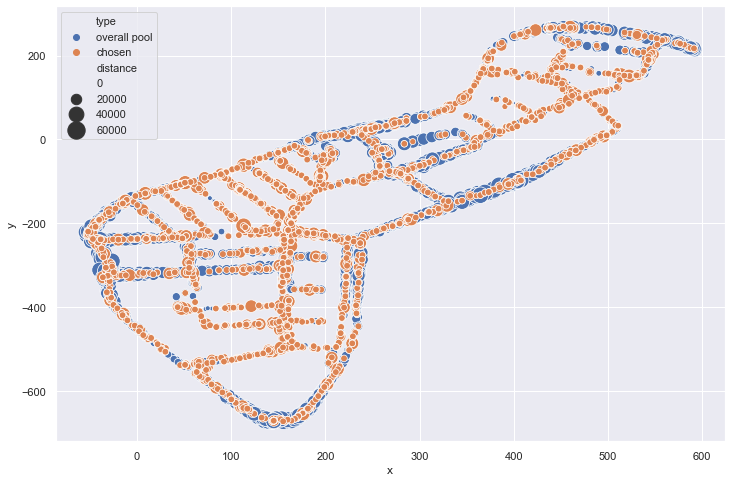

In [223]:
# Looking at the chosen samples by the random sampling method, by size
df_chosen_random["type"] = "chosen"
df_chosen_random["nearest"] = df_chosen.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_random["distance"] = df_chosen.apply(lambda row: cal_distance_to_nearest(row), axis=1)
# df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
# df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool_dist, df_chosen_random], ignore_index=True)

sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_concat, hue="type", size="distance", sizes=(0, 300))

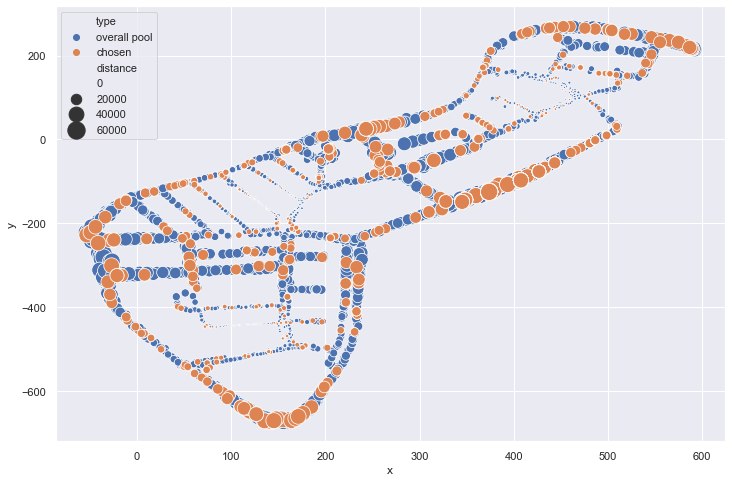

In [224]:
# Looking at the chosen samples by the uncertainty sampling method, by size
df_chosen_uncertainty["type"] = "chosen"
df_chosen_uncertainty["nearest"] = df_chosen_uncertainty.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_uncertainty["distance"] = df_chosen_uncertainty.apply(lambda row: cal_distance_to_nearest(row), axis=1)
# df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
# df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool_dist, df_chosen_uncertainty], ignore_index=True)

sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_concat, hue="type", size="distance", sizes=(0, 300))

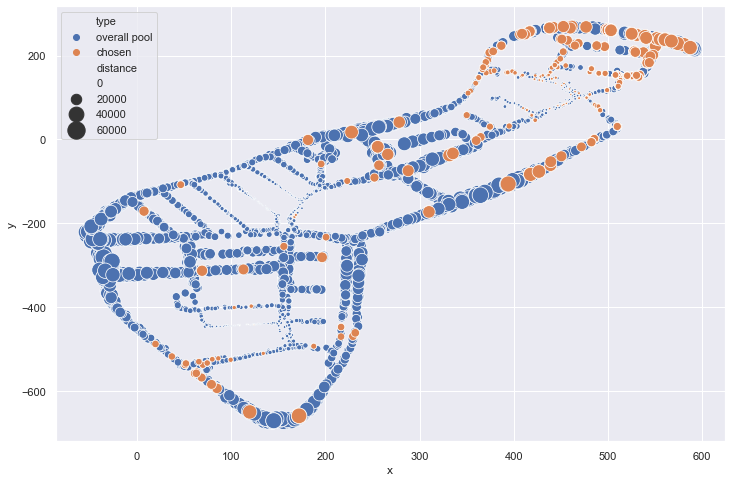

In [225]:
# Looking at the chosen samples by the margin sampling method, by size
df_chosen_margin["type"] = "chosen"
df_chosen_margin["nearest"] = df_chosen_margin.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_margin["distance"] = df_chosen_margin.apply(lambda row: cal_distance_to_nearest(row), axis=1)
# df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
# df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool_dist, df_chosen_margin], ignore_index=True)

sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_concat, hue="type", size="distance", sizes=(0, 300))

(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000.]),
 <a list of 7 Text major ticklabel objects>)

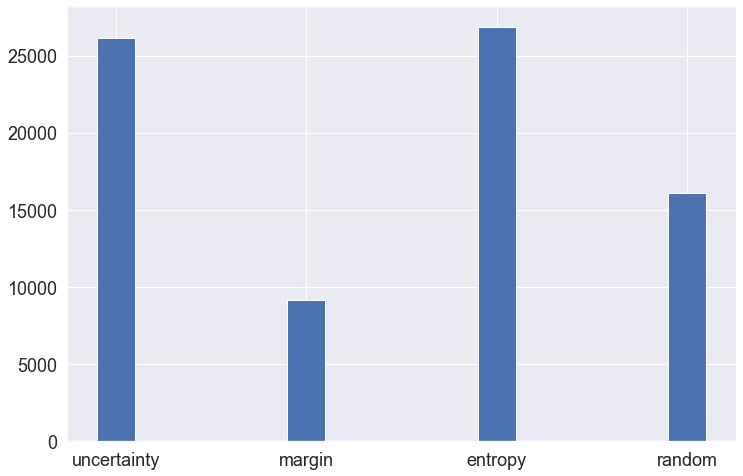

In [23]:
# get the distance of every chosen dots to its nearest centroid, for random sampling strategy
centroid0 = (df_pool[df_pool["cluster"]==0]["x"].mean(), df_pool[df_pool["cluster"]==0]["y"].mean(), df_pool[df_pool["cluster"]==0]["z"].mean())
centroid1 = (df_pool[df_pool["cluster"]==1]["x"].mean(), df_pool[df_pool["cluster"]==1]["y"].mean(), df_pool[df_pool["cluster"]==1]["z"].mean())
centroid2 = (df_pool[df_pool["cluster"]==2]["x"].mean(), df_pool[df_pool["cluster"]==2]["y"].mean(), df_pool[df_pool["cluster"]==2]["z"].mean())

def cal_distance_to_nearest(row):
    if row["nearest"] == 0:
        _ct = centroid0
    elif row["nearest"] == 1:
        _ct = centroid1
    else:
        _ct = centroid2
    return np.square(row["x"] - _ct[0]) + np.square(row["y"] - _ct[1]) + np.square(row["z"] - _ct[2])


def get_nearest_centroid(row):
    distances = [np.square(row["x"] - centroid0[0]) + np.square(row["y"] - centroid0[1]) + np.square(row["z"] - centroid0[2]),
                 np.square(row["x"] - centroid1[0]) + np.square(row["y"] - centroid1[1]) + np.square(row["z"] - centroid1[2]),
                 np.square(row["x"] - centroid2[0]) + np.square(row["y"] - centroid2[1]) + np.square(row["z"] - centroid2[2]),]
    return np.argmin(distances)


df_chosen_random = pd.read_csv("chosen/cnn_ae_al_random_all_chosen.csv", index_col=0)
df_chosen_random["nearest"] = df_chosen_random.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_random["distance"] = df_chosen_random.apply(lambda row: cal_distance_to_nearest(row), axis=1)
dist2_random = df_chosen_random["distance"].mean()

df_chosen_uncertainty = pd.read_csv("chosen/cnn_ae_al_uncertainty_all_chosen.csv", index_col=0)
df_chosen_uncertainty["nearest"] = df_chosen_uncertainty.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_uncertainty["distance"] = df_chosen_uncertainty.apply(lambda row: cal_distance_to_nearest(row), axis=1)
dist2_uncertainty = df_chosen_uncertainty["distance"].mean()

df_chosen_margin = pd.read_csv("chosen/cnn_ae_al_margin_all_chosen.csv", index_col=0)
df_chosen_margin["nearest"] = df_chosen_margin.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_margin["distance"] = df_chosen_margin.apply(lambda row: cal_distance_to_nearest(row), axis=1)
dist2_margin = df_chosen_margin["distance"].mean()

df_chosen_entropy = pd.read_csv("chosen/cnn_ae_al_entropy_all_chosen.csv", index_col=0)
df_chosen_entropy["nearest"] = df_chosen_entropy.apply(lambda row: get_nearest_centroid(row), axis=1)
df_chosen_entropy["distance"] = df_chosen_entropy.apply(lambda row: cal_distance_to_nearest(row), axis=1)
dist2_entropy = df_chosen_entropy["distance"].mean()

labels = ["uncertainty", "margin", "entropy", "random"]
plt.figure(figsize=(12, 8))
ax = plt.subplot(111)
width = 0.2
x = np.arange(len(labels))

ax.bar(x, [dist2_uncertainty, dist2_margin, dist2_entropy, dist2_random], width=width, label="distance")

ax.set_xticks(x)
ax.set_xticklabels(labels)
#plt.title("Avg distance between chosen samples and their nearest KMeans centroid")
#plt.legend()

#plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

CDF plot

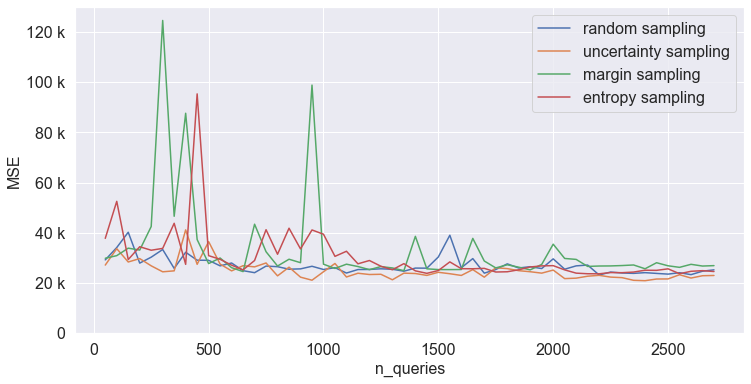

In [41]:
# MSE change over iterations

# mse_dict_random_all = {50: 38603.38415396731, 100: 82370.88192630802, 150: 43307.05292602763, 200: 28484.2737865376, 250: 27579.358404292594, 300: 30343.562950078733, 350: 67701.93577660655, 400: 32299.784316985966, 450: 37145.25167967304, 500: 113835.59726851231, 550: 33100.59150606123, 600: 29357.378790434264, 650: 28080.05916619314, 700: 27614.84726530599, 750: 27448.63793693554, 800: 28529.915769804236, 850: 28165.585971032197, 900: 32210.75674398181, 950: 28451.95431236594, 1000: 30012.122900609294, 1050: 28926.748521576752, 1100: 27067.693911817983, 1150: 26942.316022572108, 1200: 26685.504840593272, 1250: 28146.313804350604, 1300: 26775.50005560768, 1350: 28430.302043754185, 1400: 27960.471410060014, 1450: 29024.794261097184, 1500: 27688.26456234804, 1550: 27045.103976607537, 1600: 27575.284864317913, 1650: 28269.095224999113, 1700: 27458.048376353825, 1750: 25960.281637222113, 1800: 26856.849803309335, 1850: 26811.936223452358, 1900: 26786.63116298782, 1950: 26704.40241480766, 2000: 28146.67630169472, 2050: 29245.853265513928, 2100: 27262.45549392521, 2150: 27920.658066724627, 2200: 27334.347761251072, 2250: 27259.521843977887, 2300: 26982.677144396588, 2350: 25506.16868117935, 2400: 26869.41597787626, 2450: 26662.513962051406, 2500: 26975.975509946104, 2550: 24982.021808489477, 2600: 29977.882378281025, 2650: 27263.024376848523, 2700: 26981.95579496159}
mse_dict_margin_all = {50: 29821.40481648743, 100: 30871.308039142183, 150: 33853.92286885424, 200: 33097.38712443565, 250: 42480.61832460816, 300: 124604.84986029616, 350: 46564.26233910117, 400: 87622.81820558035, 450: 37279.34473166889, 500: 27712.56478250373, 550: 29929.42917439643, 600: 26071.296913237402, 650: 24514.812524831257, 700: 43398.875978404314, 750: 32425.500750460506, 800: 26732.22617998895, 850: 29442.516953009832, 900: 28063.560125103988, 950: 98848.36578742454, 1000: 27466.781059628527, 1050: 25761.763711015123, 1100: 27466.60167732113, 1150: 26532.71629379736, 1200: 25291.220250181923, 1250: 26513.418702618274, 1300: 25969.47270147198, 1350: 24880.790862666934, 1400: 38561.96813819872, 1450: 25617.76899542555, 1500: 25320.029947522464, 1550: 25312.55352379584, 1600: 25342.09005791487, 1650: 37750.50776956134, 1700: 28734.029436896813, 1750: 25981.432072836888, 1800: 27225.21827218926, 1850: 26269.2751211076, 1900: 25202.291101474806, 1950: 27370.93080536995, 2000: 35436.917383167005, 2050: 29751.63408088817, 2100: 29372.049627614837, 2150: 26577.590907386093, 2200: 26737.383452153354, 2250: 26772.38174864692, 2300: 26924.732826154283, 2350: 27151.33746812798, 2400: 25640.657674416343, 2450: 28048.637059452663, 2500: 26827.99879990675, 2550: 26206.27909723093, 2600: 27412.60647016829, 2650: 26726.064110701922, 2700: 26891.37075944076}
mse_dict_entropy_all = {50: 37760.839949203226, 100: 52514.74166678015, 150: 29314.805617568385, 200: 34425.252486909856, 250: 33028.82767989704, 300: 33758.33199665399, 350: 43768.48940746294, 400: 27400.072574042497, 450: 95341.77410672784, 500: 30867.678634371885, 550: 29405.61141941858, 600: 27077.012369224245, 650: 25206.123718817602, 700: 28925.852146549947, 750: 41207.524985913384, 800: 31427.596333331512, 850: 41799.75375281047, 900: 33551.08027318086, 950: 41109.24316119926, 1000: 39402.749341861454, 1050: 30586.26293455437, 1100: 32620.544267312038, 1150: 27616.910399366196, 1200: 28930.813398844697, 1250: 26645.702321173052, 1300: 25238.631388471553, 1350: 27686.618869832575, 1400: 24812.54740021528, 1450: 23817.322531766447, 1500: 24930.80151415366, 1550: 28377.414426094907, 1600: 25672.415114601437, 1650: 25640.143351852803, 1700: 25804.841529447887, 1750: 24345.59939155509, 1800: 24443.996048605186, 1850: 25233.656711826785, 1900: 26358.06631704122, 1950: 26780.351090257696, 2000: 26883.854810218156, 2050: 25193.357154293626, 2100: 23896.80700430101, 2150: 23656.62883111708, 2200: 23633.791854528565, 2250: 24122.94796684233, 2300: 24080.56775897609, 2350: 24325.098912270845, 2400: 25060.510465544776, 2450: 25010.31655314428, 2500: 25615.528266323865, 2550: 23674.10418635835, 2600: 24629.649132655268, 2650: 24890.087560064494, 2700: 24541.71166163973}
mse_dict_uncertainty_all = {50: 27107.219202267286, 100: 33651.20570181082, 150: 28340.753283912938, 200: 29696.204791289023, 250: 26811.734490214993, 300: 24433.969427324784, 350: 24811.324275313007, 400: 41137.44736704145, 450: 27414.12814883786, 500: 36465.449015590246, 550: 27512.078565816613, 600: 24793.099727730627, 650: 26875.91182106898, 700: 26396.953156388307, 750: 27948.07015247204, 800: 22814.96434885432, 850: 26273.801472898205, 900: 22300.214966397034, 950: 21079.69516115019, 1000: 24443.417724652318, 1050: 27743.478090552697, 1100: 22364.911158387185, 1150: 23860.3726355588, 1200: 23349.96024689362, 1250: 23441.925819656826, 1300: 21250.48502635538, 1350: 23897.388078192245, 1400: 23745.500917314057, 1450: 22994.309918734256, 1500: 24234.866440333502, 1550: 23660.998073809013, 1600: 22981.95288404224, 1650: 25310.500843009406, 1700: 22288.33078460753, 1750: 26053.121641889677, 1800: 25698.39849464991, 1850: 24880.691010910097, 1900: 24459.147987713048, 1950: 23896.786388063498, 2000: 25119.413374497115, 2050: 21719.050057216013, 2100: 21897.900128168145, 2150: 22678.12495071921, 2200: 23022.56039131879, 2250: 22319.459878956335, 2300: 22100.63762287857, 2350: 21039.05813805297, 2400: 20885.247500492787, 2450: 21555.940294293338, 2500: 21590.32062422366, 2550: 23265.21461294517, 2600: 21943.014020790793, 2650: 22865.022263969546, 2700: 22969.14348000953}

mse_dict_random_all = {50: 29171.10903484117, 100: 34102.51781554835, 150: 40201.7350971013, 200: 27894.923342939222, 250: 30262.32896053487, 300: 33314.44406860369, 350: 25790.102550186453, 400: 32217.01328453615, 450: 29056.37014118546, 500: 29009.870140439813, 550: 26803.534499490623, 600: 27939.71098851819, 650: 24881.50449703178, 700: 24080.123515634015, 750: 26711.704947116374, 800: 26472.827871963604, 850: 25464.06984894017, 900: 25597.13008338962, 950: 26634.315132638887, 1000: 25351.759986798108, 1050: 26076.85110076665, 1100: 23938.359206179073, 1150: 25329.434256172153, 1200: 25365.673872573538, 1250: 25626.672128620005, 1300: 25444.09230721252, 1350: 24665.978926264284, 1400: 25911.542830490846, 1450: 25877.711651590278, 1500: 30346.778856299334, 1550: 39002.494301724684, 1600: 26047.524538693076, 1650: 29695.413844664752, 1700: 23891.937378745137, 1750: 25334.553858377098, 1800: 27598.623275540518, 1850: 25949.43272343818, 1900: 26467.94007474519, 1950: 25722.189210156226, 2000: 29590.569372465063, 2050: 25467.396228394467, 2100: 26796.829419014157, 2150: 27118.580546445923, 2200: 23159.700865669805, 2250: 24335.196898140974, 2300: 23945.190703479984, 2350: 23805.673266046317, 2400: 24092.240420583785, 2450: 23790.832890304897, 2500: 23507.758863536936, 2550: 24073.15737257837, 2600: 23299.61787483813, 2650: 24667.223594086765, 2700: 25213.82946977021}

n_queries = list(mse_dict_random_all.keys())
mses_random_all = list(mse_dict_random_all.values())
mses_uncertainty_all = list(mse_dict_uncertainty_all.values())
mses_margin_all = list(mse_dict_margin_all.values())
mses_entropy_all = list(mse_dict_entropy_all.values())

font_size = 16
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
plt.plot(n_queries, mses_random_all, label="random sampling")
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling")
plt.plot(n_queries, mses_margin_all, label="margin sampling")
plt.plot(n_queries, mses_entropy_all, label="entropy sampling")

plt.ylabel("MSE", fontsize=font_size)
plt.xlabel("n_queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 130000))
ax.yaxis.set_major_formatter(ticker.EngFormatter())


Text(0.5, 0, 'MSE')

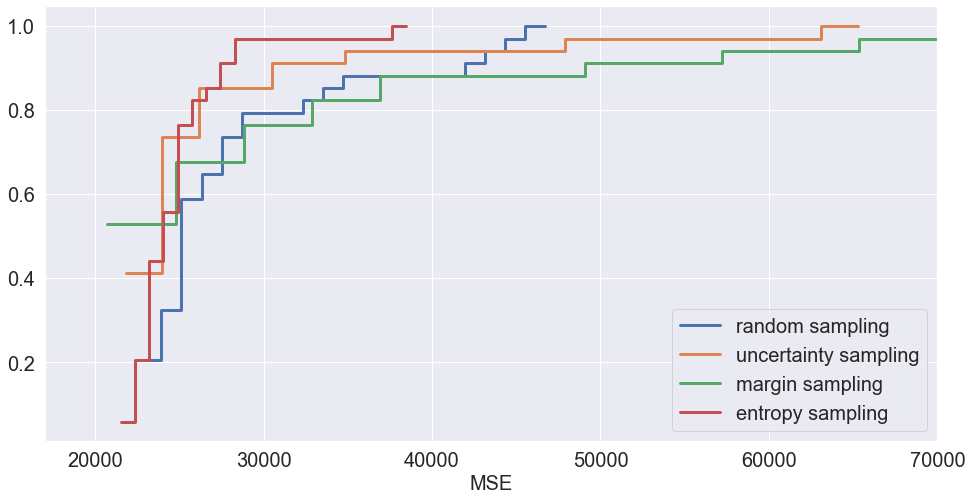

In [14]:
fig, ax = plt.subplots(figsize=(16, 8))
font_size = 20
line_width = 3
def plot_qs_cdf(qs_name, qs_var):
    counts, bins = np.histogram(qs_var, bins=20)
    cdf = np.cumsum(counts)/np.sum(counts)

    plt.plot(
        np.vstack((bins, np.roll(bins, -1))).T.flatten()[:-2],
        np.vstack((cdf, cdf)).T.flatten(), label=f"{qs_name} sampling",
        linewidth=line_width
    )

plot_qs_cdf("random", mses_random_all)
plot_qs_cdf("uncertainty", mses_uncertainty_all)
plot_qs_cdf("margin", mses_margin_all)
plot_qs_cdf("entropy", mses_entropy_all)


plt.xlim(17000, 70000)
plt.legend(loc="lower right", prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)

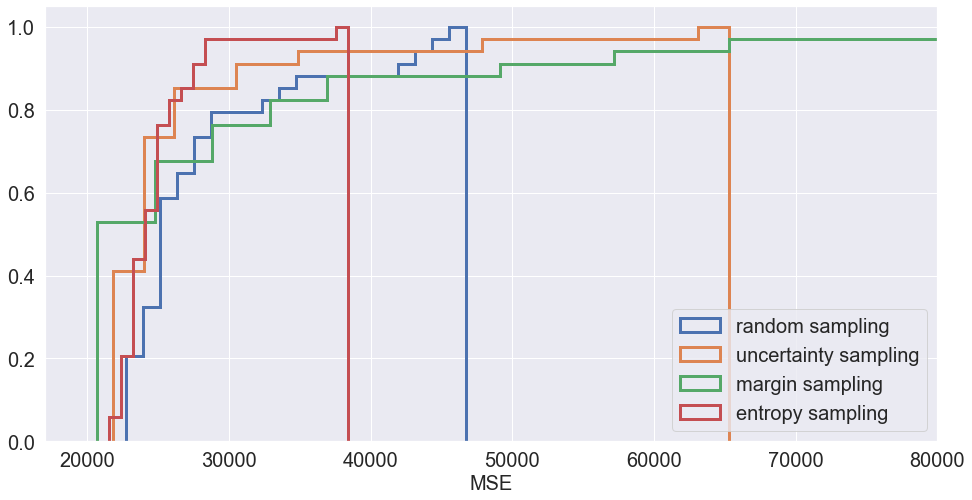

In [13]:
n_bins = 20
alpha = 1
font_size = 20
line_width = 3
fig, ax = plt.subplots(figsize=(16, 8))
ax.hist(mses_random_all, n_bins, cumulative=True, label='random sampling', density=True,
         histtype='step', alpha=alpha, linewidth=line_width)
# labels = ax.get_yticklabels()
# print(labels)
ax.hist(mses_uncertainty_all, n_bins, cumulative=True, label='uncertainty sampling', density=True,
         histtype='step', alpha=alpha, linewidth=line_width)
ax.hist(mses_margin_all, n_bins, cumulative=True, label='margin sampling', density=True,
         histtype='step', alpha=alpha, linewidth=line_width)
ax.hist(mses_entropy_all, n_bins, cumulative=True, label='entropy sampling', density=True,
         histtype='step', alpha=alpha, linewidth=line_width)
plt.xlim(17000, 80000)
plt.legend(loc="lower right", prop={'size': font_size})

#plt.ylabel("mse", fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE")

from matplotlib.ticker import MaxNLocator
#ax.yaxis.set_major_locator(MaxNLocator(prune='lower', nbins=5, steps=2))
# labels[0] = ""
# ax.set_yticklabels(labels)

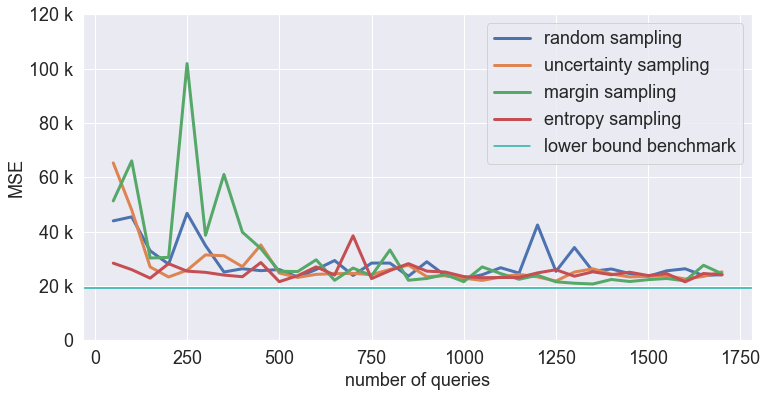

In [11]:
# after bootstrap
mse_dict_uncertainty_all = {50: 65274.10617262323, 100: 47983.413478226925, 150: 26983.203641819764, 200: 23294.31099955719, 250: 25767.44701760128, 300: 31415.140141454478, 350: 31105.991843989013, 400: 27092.073001079134, 450: 35079.79240952116, 500: 24737.2838222193, 550: 23151.96876497875, 600: 24261.26749647967, 650: 24512.062144447933, 700: 24604.692696459675, 750: 24176.277237716175, 800: 26059.26547327766, 850: 27632.748908348494, 900: 23435.436915971364, 950: 23772.73363501368, 1000: 22879.49065328263, 1050: 22032.062414307245, 1100: 23282.969981022256, 1150: 24243.42911624546, 1200: 23321.90422994128, 1250: 21807.755052372228, 1300: 25105.341141332796, 1350: 26304.221968649636, 1400: 24385.826748441923, 1450: 23298.717850202564, 1500: 23529.185271881477, 1550: 23792.64497272381, 1600: 22563.45969709588, 1650: 23508.140939580797, 1700: 25171.42693264304}
#mse_dict_random_all = {50: 71617.91123259407, 100: 76118.1079766072, 150: 26086.271611031905, 200: 25181.25968761669, 250: 25322.951496414305, 300: 44272.461741440486, 350:28398.824795304216, 400: 30680.718211711486, 450: 23913.075120752295, 500: 28074.190426629528, 550: 24939.382280740578, 600: 23736.4471744714, 650:22734.727656826475, 700: 24395.607630646726, 750: 25501.077709358007, 800: 25672.07353906204, 850: 28486.351716797435, 900: 32292.158496871547, 950:24151.577356446844, 1000: 23239.365246587506, 1050: 24791.677627518457, 1100: 25554.58103941589, 1150: 25686.368855251323, 1200: 25284.24356900402, 1250:25240.157766592307, 1300: 21225.440121947988, 1350: 23064.65967220269, 1400: 25142.367011513652, 1450: 23354.720628641415, 1500: 22440.945236014813, 1550:23349.91761343894, 1600: 24086.09442071166, 1650: 22419.511648289732, 1700: 21843.26741914726}
mse_dict_random_all = {50: 43938.65473272116, 100: 45414.48644163506, 150: 32936.1708191538, 200: 28020.95655935872, 250: 46733.35922744398, 300: 34855.51274405723, 350: 25121.05109737441, 400: 26326.092118955086, 450: 25623.495805314145, 500: 26046.956065929753, 550: 23262.249193148164, 600: 26053.763465327404, 650: 29358.360986277115, 700: 23846.1502608646, 750: 28413.213935541935, 800: 28401.46385156857, 850: 23584.242291479484, 900: 28901.89881011218, 950: 23808.375253824895, 1000: 22714.573657607438, 1050: 24120.740246977162, 1100: 26703.728214707702, 1150: 24717.33998396136, 1200: 42419.127575922765, 1250: 25372.907570312494, 1300: 34131.830719717196, 1350: 25395.34618173241, 1400: 26233.997076685435, 1450: 24542.40961228075, 1500: 23536.65718857488, 1550: 25567.64369904011, 1600: 26314.55865681308, 1650: 23815.499750545205, 1700: 24171.411069551297}

mse_dict_margin_all = {50: 51284.7889639079, 100: 66016.85194045343, 150: 30273.315947502284, 200: 30510.82017951523, 250: 101819.90187829953, 300: 38640.28536421815, 350: 61023.50973416321, 400: 39791.17053809991, 450: 33765.272898954434, 500: 25399.624299885418, 550: 25295.027473948994, 600: 29622.44115548955, 650: 22079.748127691277, 700: 26585.907866276033, 750: 23744.630069383275, 800: 33232.0238208386, 850: 22102.53742151872, 900: 22752.360947639696, 950: 24208.144510679806, 1000: 21562.274649640396, 1050: 26998.73762918318, 1100: 24560.675992117074, 1150: 22452.813376793336, 1200: 23929.085556499747, 1250: 21515.396521110073, 1300: 21002.850865800327, 1350: 20719.38535556257, 1400: 22377.759285214455, 1450: 21627.643168845763, 1500: 22310.4018052671, 1550: 22741.272950609113, 1600: 21881.32329409153, 1650: 27603.12559227485, 1700: 24481.910818201824}
mse_dict_entropy_all = {50: 28380.728995871905, 100: 25999.777289061687, 150: 22867.76505331373, 200: 28199.529204771632, 250: 25441.47017795502, 300: 25003.850975922735, 350: 23999.76663088189, 400: 23389.13185333071, 450: 28617.153615144096, 500: 21572.535891404164, 550: 23780.802876654794, 600: 27012.64679644414, 650: 24011.72121292667, 700: 38444.200770061805, 750: 22689.47333404826, 800: 25654.592084456395, 850: 28205.596121859, 900: 25440.040743286863, 950: 25117.27085514094, 1000: 23442.317186662574, 1050: 23036.608919064194, 1100: 23096.5961593425, 1150: 23124.530170379745, 1200: 24805.102946529525, 1250: 25953.39294655282, 1300: 23577.54266208186, 1350: 25200.517051388724, 1400: 24119.660713122023, 1450: 25046.87818086985, 1500: 23816.1011390917, 1550: 24551.050842369663, 1600: 21517.733642173673, 1650: 24585.92453574138, 1700: 24052.50585216122}
n_queries = list(mse_dict_uncertainty_all.keys())
mses_random_all = list(mse_dict_random_all.values())
mses_uncertainty_all = list(mse_dict_uncertainty_all.values())
mses_margin_all = list(mse_dict_margin_all.values())
mses_entropy_all = list(mse_dict_entropy_all.values())


font_size = 18
line_width = 3
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
plt.plot(n_queries, mses_random_all, label="random sampling", linewidth=line_width)
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling", linewidth=line_width)
plt.plot(n_queries, mses_margin_all, label="margin sampling", linewidth=line_width)
plt.plot(n_queries, mses_entropy_all, label="entropy sampling", linewidth=line_width)
y_bm = 19258.3560
plt.axhline(y=y_bm, color='lightseagreen', linestyle='-', label="lower bound benchmark")

plt.ylabel("MSE", fontsize=font_size)
plt.xlabel("number of queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 120000))
ax.yaxis.set_major_formatter(ticker.EngFormatter())

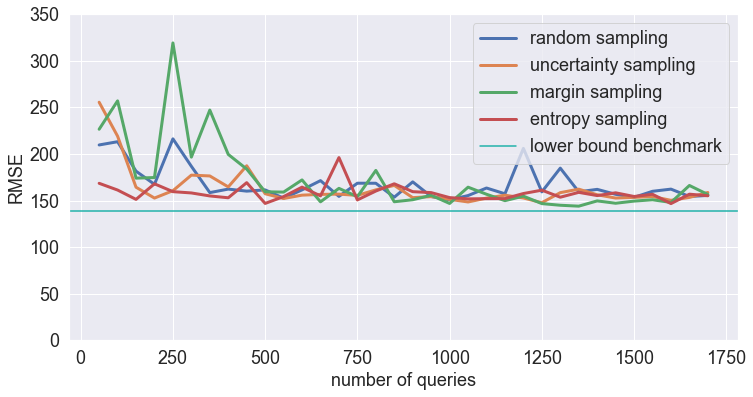

In [47]:
# after bootstrap
import math
mse_dict_uncertainty_all = {50: 65274.10617262323, 100: 47983.413478226925, 150: 26983.203641819764, 200: 23294.31099955719, 250: 25767.44701760128, 300: 31415.140141454478, 350: 31105.991843989013, 400: 27092.073001079134, 450: 35079.79240952116, 500: 24737.2838222193, 550: 23151.96876497875, 600: 24261.26749647967, 650: 24512.062144447933, 700: 24604.692696459675, 750: 24176.277237716175, 800: 26059.26547327766, 850: 27632.748908348494, 900: 23435.436915971364, 950: 23772.73363501368, 1000: 22879.49065328263, 1050: 22032.062414307245, 1100: 23282.969981022256, 1150: 24243.42911624546, 1200: 23321.90422994128, 1250: 21807.755052372228, 1300: 25105.341141332796, 1350: 26304.221968649636, 1400: 24385.826748441923, 1450: 23298.717850202564, 1500: 23529.185271881477, 1550: 23792.64497272381, 1600: 22563.45969709588, 1650: 23508.140939580797, 1700: 25171.42693264304}
#mse_dict_random_all = {50: 71617.91123259407, 100: 76118.1079766072, 150: 26086.271611031905, 200: 25181.25968761669, 250: 25322.951496414305, 300: 44272.461741440486, 350:28398.824795304216, 400: 30680.718211711486, 450: 23913.075120752295, 500: 28074.190426629528, 550: 24939.382280740578, 600: 23736.4471744714, 650:22734.727656826475, 700: 24395.607630646726, 750: 25501.077709358007, 800: 25672.07353906204, 850: 28486.351716797435, 900: 32292.158496871547, 950:24151.577356446844, 1000: 23239.365246587506, 1050: 24791.677627518457, 1100: 25554.58103941589, 1150: 25686.368855251323, 1200: 25284.24356900402, 1250:25240.157766592307, 1300: 21225.440121947988, 1350: 23064.65967220269, 1400: 25142.367011513652, 1450: 23354.720628641415, 1500: 22440.945236014813, 1550:23349.91761343894, 1600: 24086.09442071166, 1650: 22419.511648289732, 1700: 21843.26741914726}
mse_dict_random_all = {50: 43938.65473272116, 100: 45414.48644163506, 150: 32936.1708191538, 200: 28020.95655935872, 250: 46733.35922744398, 300: 34855.51274405723, 350: 25121.05109737441, 400: 26326.092118955086, 450: 25623.495805314145, 500: 26046.956065929753, 550: 23262.249193148164, 600: 26053.763465327404, 650: 29358.360986277115, 700: 23846.1502608646, 750: 28413.213935541935, 800: 28401.46385156857, 850: 23584.242291479484, 900: 28901.89881011218, 950: 23808.375253824895, 1000: 22714.573657607438, 1050: 24120.740246977162, 1100: 26703.728214707702, 1150: 24717.33998396136, 1200: 42419.127575922765, 1250: 25372.907570312494, 1300: 34131.830719717196, 1350: 25395.34618173241, 1400: 26233.997076685435, 1450: 24542.40961228075, 1500: 23536.65718857488, 1550: 25567.64369904011, 1600: 26314.55865681308, 1650: 23815.499750545205, 1700: 24171.411069551297}

mse_dict_margin_all = {50: 51284.7889639079, 100: 66016.85194045343, 150: 30273.315947502284, 200: 30510.82017951523, 250: 101819.90187829953, 300: 38640.28536421815, 350: 61023.50973416321, 400: 39791.17053809991, 450: 33765.272898954434, 500: 25399.624299885418, 550: 25295.027473948994, 600: 29622.44115548955, 650: 22079.748127691277, 700: 26585.907866276033, 750: 23744.630069383275, 800: 33232.0238208386, 850: 22102.53742151872, 900: 22752.360947639696, 950: 24208.144510679806, 1000: 21562.274649640396, 1050: 26998.73762918318, 1100: 24560.675992117074, 1150: 22452.813376793336, 1200: 23929.085556499747, 1250: 21515.396521110073, 1300: 21002.850865800327, 1350: 20719.38535556257, 1400: 22377.759285214455, 1450: 21627.643168845763, 1500: 22310.4018052671, 1550: 22741.272950609113, 1600: 21881.32329409153, 1650: 27603.12559227485, 1700: 24481.910818201824}
mse_dict_entropy_all = {50: 28380.728995871905, 100: 25999.777289061687, 150: 22867.76505331373, 200: 28199.529204771632, 250: 25441.47017795502, 300: 25003.850975922735, 350: 23999.76663088189, 400: 23389.13185333071, 450: 28617.153615144096, 500: 21572.535891404164, 550: 23780.802876654794, 600: 27012.64679644414, 650: 24011.72121292667, 700: 38444.200770061805, 750: 22689.47333404826, 800: 25654.592084456395, 850: 28205.596121859, 900: 25440.040743286863, 950: 25117.27085514094, 1000: 23442.317186662574, 1050: 23036.608919064194, 1100: 23096.5961593425, 1150: 23124.530170379745, 1200: 24805.102946529525, 1250: 25953.39294655282, 1300: 23577.54266208186, 1350: 25200.517051388724, 1400: 24119.660713122023, 1450: 25046.87818086985, 1500: 23816.1011390917, 1550: 24551.050842369663, 1600: 21517.733642173673, 1650: 24585.92453574138, 1700: 24052.50585216122}
n_queries = list(mse_dict_uncertainty_all.keys())
mses_random_all = [math.sqrt(a) for a in list(mse_dict_random_all.values())]
mses_uncertainty_all = [math.sqrt(a) for a in list(mse_dict_uncertainty_all.values())]
mses_margin_all = [math.sqrt(a) for a in list(mse_dict_margin_all.values())]
mses_entropy_all = [math.sqrt(a) for a in list(mse_dict_entropy_all.values())]


font_size = 18
line_width = 3
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
plt.plot(n_queries, mses_random_all, label="random sampling", linewidth=line_width)
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling", linewidth=line_width)
plt.plot(n_queries, mses_margin_all, label="margin sampling", linewidth=line_width)
plt.plot(n_queries, mses_entropy_all, label="entropy sampling", linewidth=line_width)
y_bm = math.sqrt(19258.3560)
plt.axhline(y=y_bm, color='lightseagreen', linestyle='-', label="lower bound benchmark")

plt.ylabel("RMSE", fontsize=font_size)
plt.xlabel("number of queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 350))
ax.yaxis.set_major_formatter(ticker.EngFormatter())

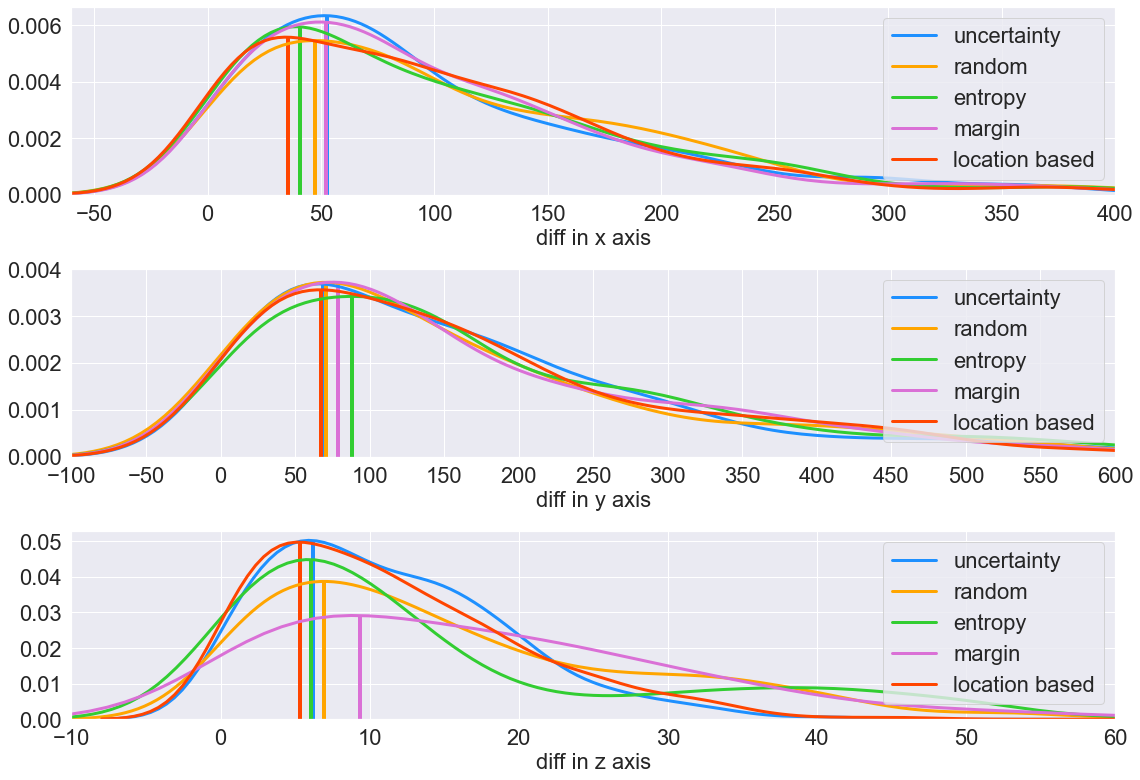

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11))
colors = {
    "uncertainty": "dodgerblue",
    "margin": "orchid",
    "entropy": "limegreen",
    "random": "orange",
    "location based": "orangered",
    "full": "slategray"
}
line_width = 3
v_line_width = 4
font_size = 22
sns.set()

def plot_diff_kde(filename, label, line_idx, axis="x"):
    preds = pd.read_csv(f"preds/{filename}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test_ae, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], axis=1, ignore_index=True)
    concat.columns = ["x_p", "y_p", "z_p", "t1", "x_t", "y_t", "z_t", "t2"]
    concat[f"{axis}_diff"] = abs(concat[f"{axis}_p"] - concat[f"{axis}_t"])
    p = sns.kdeplot(concat[f"{axis}_diff"], label=label, color=colors[label], linewidth=line_width)
    x, y = p.get_lines()[line_idx].get_data()
    y_argmax = np.argmax(y)
    x_curt = (x[y_argmax] + x[y_argmax + 1]) / 2
    
    plt.vlines(x_curt, 0, y[y_argmax], color=colors[label], linewidth=v_line_width)
    if axis == "x":
        plt.xlim(-60, 400)
        plt.xticks(np.arange(-50, 450, 50))
        plt.yticks([0, 0.002, 0.004, 0.006])
    elif axis == "y":
        plt.xlim(-100, 600)
        plt.xticks(np.arange(-100, 650, 50))
        plt.yticks([0, 0.001, 0.002, 0.003, 0.004])
    elif axis == "z":
        plt.xticks(np.arange(-10, 70, 10))
        plt.xlim(-10, 60)
    plt.legend()
    plt.ylabel("")
    plt.xlabel(f"diff in {axis} axis", fontsize=font_size)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    
plt.subplot(3, 1, 1)
plot_diff_kde("cnn_ae_al1_uncertainty_all_preds.csv", "uncertainty", 0, "x")
plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "x")
plot_diff_kde("cnn_ae_al1_entropy_all_preds.csv", "entropy", 2, "x")
plot_diff_kde("cnn_ae_al1_margin_all_preds.csv", "margin", 3, "x")
plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "x")
#plot_diff_kde("cnn_ae_full_all_preds.csv", "full", 5, "x")

plt.subplot(3, 1, 2)
plot_diff_kde("cnn_ae_al1_uncertainty_all_preds.csv", "uncertainty", 0, "y")
plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "y")
plot_diff_kde("cnn_ae_al1_entropy_all_preds.csv", "entropy", 2, "y")
plot_diff_kde("cnn_ae_al1_margin_all_preds.csv", "margin", 3, "y")
plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "y")
#plot_diff_kde("cnn_ae_full_all_preds.csv", "full", 5, "y")

plt.subplot(3, 1, 3)
plot_diff_kde("cnn_ae_al1_uncertainty_all_preds.csv", "uncertainty", 0, "z")
plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "z")
plot_diff_kde("cnn_ae_al1_entropy_all_preds.csv", "entropy", 2, "z")
plot_diff_kde("cnn_ae_al1_margin_all_preds.csv", "margin", 3, "z")
plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "z")
#plot_diff_kde("cnn_ae_full_all_preds.csv", "full", 5, "z")

fig.tight_layout()